# Vaccines Overview


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(r'C:\Users\ThinkPad\Desktop\Mastermind\WHO\WHO_health_indicators\CSV_files\WHS2025_DATADOWNLOAD.csv')
indicator_list=pd.read_csv(r'C:\Users\ThinkPad\Desktop\Mastermind\WHO\WHO_health_indicators\CSV_files\indicator_list.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9729 entries, 0 to 9728
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IndicatorName   9729 non-null   str    
 1   IndicatorCode   9729 non-null   str    
 2   Location        9729 non-null   str    
 3   LocationCode    9729 non-null   str    
 4   Year            9729 non-null   str    
 5   Disaggregation  1517 non-null   str    
 6   NumericValue    9665 non-null   float64
 7   DisplayValue    9727 non-null   str    
 8   Comments        2722 non-null   str    
dtypes: float64(1), str(8)
memory usage: 684.2 KB


### Creating a df with only vaccine indicators

In [ ]:
mask = df['IndicatorName'].str.contains(r'vaccine|immunization', case=False, na=False)
vaccine_df = df[mask].copy()
vaccine_df["IndicatorName"].unique()


<class 'pandas.DataFrame'>
Index: 703 entries, 2039 to 5749
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IndicatorName   703 non-null    str    
 1   IndicatorCode   703 non-null    str    
 2   Location        703 non-null    str    
 3   LocationCode    703 non-null    str    
 4   Year            703 non-null    str    
 5   Disaggregation  0 non-null      str    
 6   NumericValue    703 non-null    float64
 7   DisplayValue    703 non-null    str    
 8   Comments        0 non-null      str    
dtypes: float64(1), str(8)
memory usage: 54.9 KB


In [6]:
vaccine_df["Year"].unique()

<StringArray>
['2023']
Length: 1, dtype: str

In [19]:
vacc_countries=vaccine_df["Location"]
vacc_countries.to_csv(r'C:\Users\ThinkPad\Desktop\Mastermind\WHO\WHO_health_indicators\CSV_files\vaccine_countries.csv', index=False)


### -> the entire dataset for vaccines is about the year 2023
### Shorten the countries for easier annotation in plots

In [26]:
shorten = {
    "Democratic People's Republic of Korea": "North Korea",
    "Democratic Republic of the Congo": "DR Congo",
    "Lao People's Democratic Republic": "Laos",
    "occupied Palestinian territory, including east Jerusalem": "Palestine",
    "Republic of Korea": "South Korea",
    "Republic of Moldova": "Moldova",
    "Russian Federation": "Russia",
    "Saint Vincent and the Grenadines": "St. Vincent & Grenadines",
    "Syrian Arab Republic": "Syria",
    "United Republic of Tanzania": "Tanzania",
    "United States of America": "USA",
    "United Arab Emirates": "UAE",
    "Central African Republic": "C.A.R.",
    "Saint Kitts and Nevis": "St. Kitts & Nevis",
    "Sao Tome and Principe": "São Tomé & Príncipe",
    "Eastern Mediterranean Region": "E. Mediterranean Reg.",
    "South-East Asia Region": "SE Asia Reg.",
    "Region of the Americas": "Americas Reg.",
    "Western Pacific Region": "W. Pacific Reg.",
    "Brunei Darussalam": "Brunei",
}

# 1) strip parentheticals → handles Bolivia, Iran, Micronesia, Netherlands, Venezuela
vaccine_df['LocationShort'] = vaccine_df['Location'].str.replace(r'\s*\(.*\)', '', regex=True)
# 2) apply the manual shortenings above
vaccine_df['LocationShort'] = vaccine_df['LocationShort'].replace(shorten)
vaccine_df.info()
vaccine_df.to_csv(r'C:\Users\ThinkPad\Desktop\Mastermind\WHO\WHO_health_indicators\CSV_files\vaccine_indicators.csv', index=False)
vaccine_df.info()

<class 'pandas.DataFrame'>
Index: 703 entries, 2039 to 5749
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IndicatorName   703 non-null    str    
 1   IndicatorCode   703 non-null    str    
 2   Location        703 non-null    str    
 3   LocationCode    703 non-null    str    
 4   Year            703 non-null    str    
 5   Disaggregation  0 non-null      str    
 6   NumericValue    703 non-null    float64
 7   DisplayValue    703 non-null    str    
 8   Comments        0 non-null      str    
 9   LocationShort   703 non-null    str    
 10  Vaccine         703 non-null    str    
dtypes: float64(1), str(10)
memory usage: 65.9 KB
<class 'pandas.DataFrame'>
Index: 703 entries, 2039 to 5749
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IndicatorName   703 non-null    str    
 1   IndicatorCode   703 non-null    str    

c:\Users\ThinkPad\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 24.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ThinkPad\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ThinkPad\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ThinkPad\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 24.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


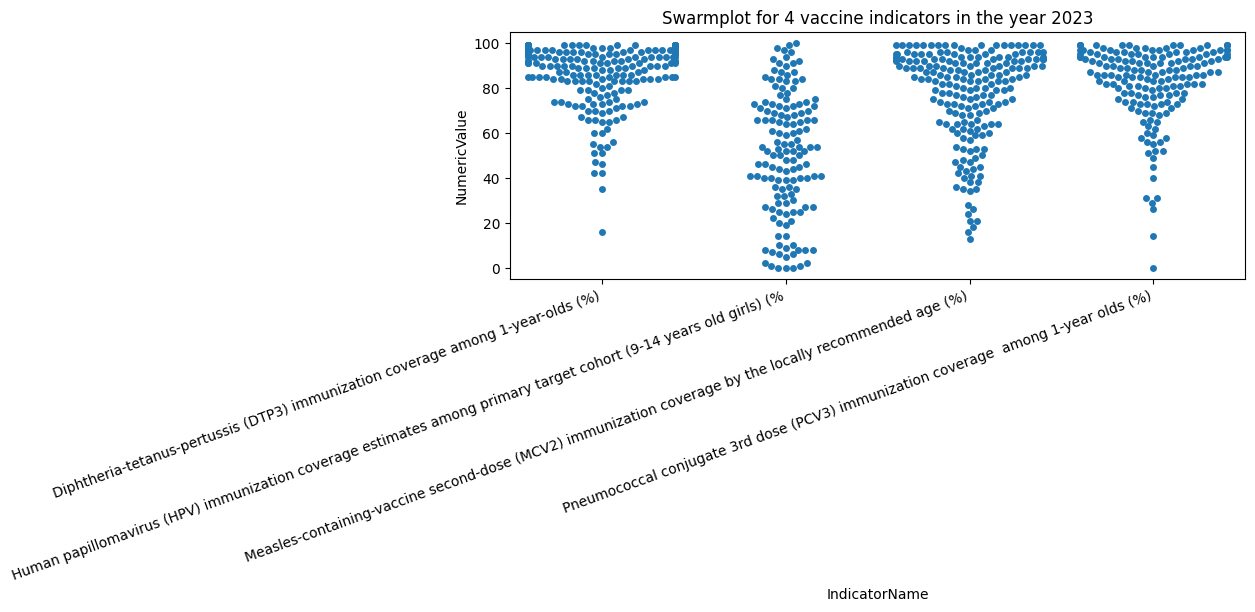

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.swarmplot(data=vaccine_df, x='IndicatorName', y='NumericValue')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.title("Swarmplot for 4 vaccine indicators in the year 2023")
plt.savefig('vaccine_swarmplot_4_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

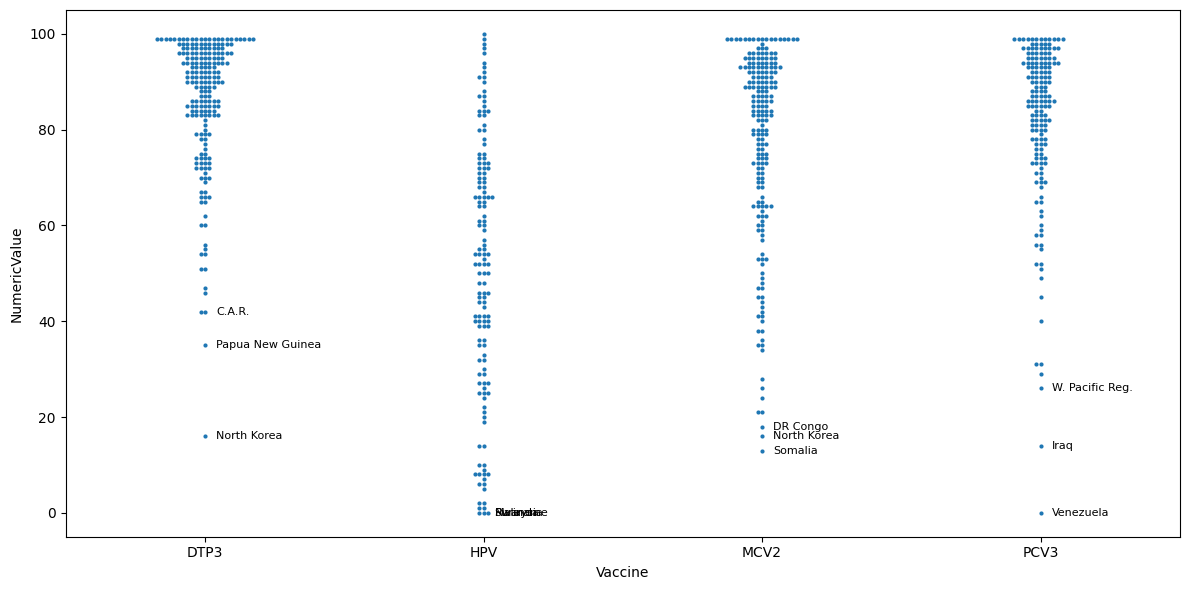

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

vaccine_df['Location'] = vaccine_df['Location'].replace(
    'Venezuela (Bolivarian Republic of)', 'Venezuela'
)
short = {
    'Diphtheria-tetanus-pertussis (DTP3) immunization coverage among 1-year-olds (%)': 'DTP3',
    'Human papillomavirus (HPV) immunization coverage estimates among primary target cohort (9-14 years old girls) (%': 'HPV',  # no closing )
    'Measles-containing-vaccine second-dose (MCV2) immunization coverage by the locally recommended age (%)': 'MCV2',
    'Pneumococcal conjugate 3rd dose (PCV3) immunization coverage  among 1-year olds (%)': 'PCV3',
}
vaccine_df['Vaccine'] = vaccine_df['IndicatorName'].map(short)
order = ['DTP3', 'HPV', 'MCV2', 'PCV3']

plt.figure(figsize=(12, 6))
ax = sns.swarmplot(data=vaccine_df, x='Vaccine', y='NumericValue', order=order, size=3)

for i, cat in enumerate(order):
    lowest3 = vaccine_df[vaccine_df['Vaccine'] == cat].nsmallest(3, 'NumericValue')
    for _, row in lowest3.iterrows():
        ax.annotate(
            row['LocationShort'],
            xy=(i, row['NumericValue']),
            xytext=(8, 0),
            textcoords='offset points',
            fontsize=8,
            va='center',
        )

plt.tight_layout()
plt.savefig('vaccine_swarmplot.png', dpi=300, bbox_inches='tight')
plt.show()

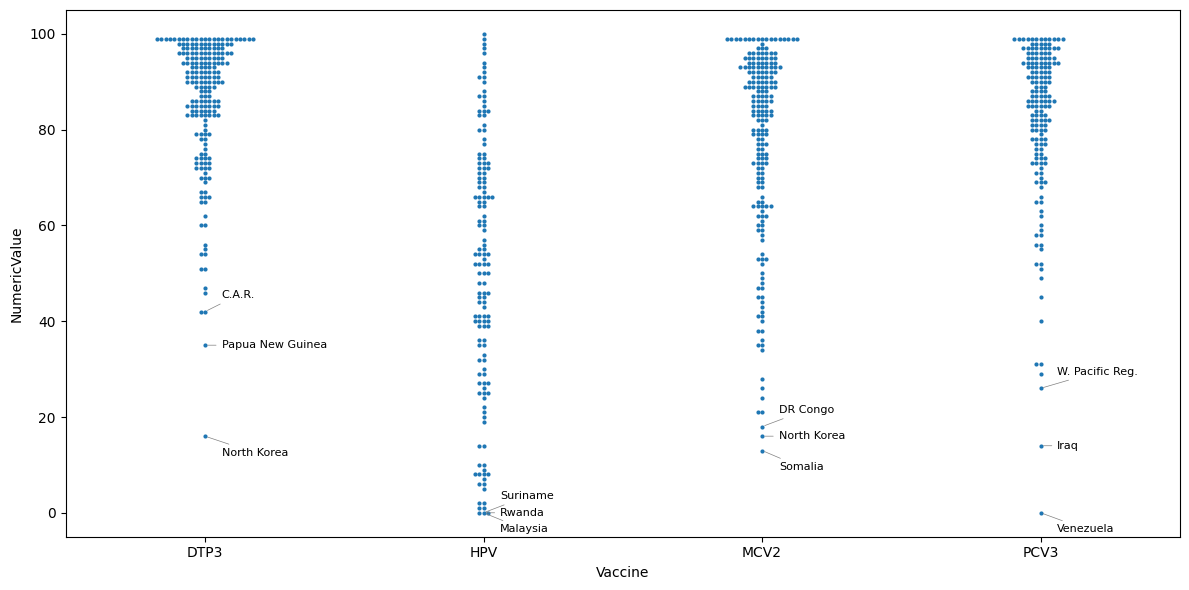

In [27]:
import os

os.makedirs('Plot_pictures', exist_ok=True)

plt.figure(figsize=(12, 6))
ax = sns.swarmplot(data=vaccine_df, x='Vaccine', y='NumericValue', order=order, size=3)

for i, cat in enumerate(order):
    lowest3 = (vaccine_df[vaccine_df['Vaccine'] == cat]
               .nsmallest(3, 'NumericValue')
               .reset_index(drop=True))
    for j, row in lowest3.iterrows():
        ax.annotate(
            row['LocationShort'],
            xy=(i, row['NumericValue']),
            xytext=(12, (j - 1) * 12),   # spread vertically: -12, 0, +12 px
            textcoords='offset points',
            fontsize=8,
            va='center',
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
        )

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_swarmplot.png', dpi=300, bbox_inches='tight')
plt.show()

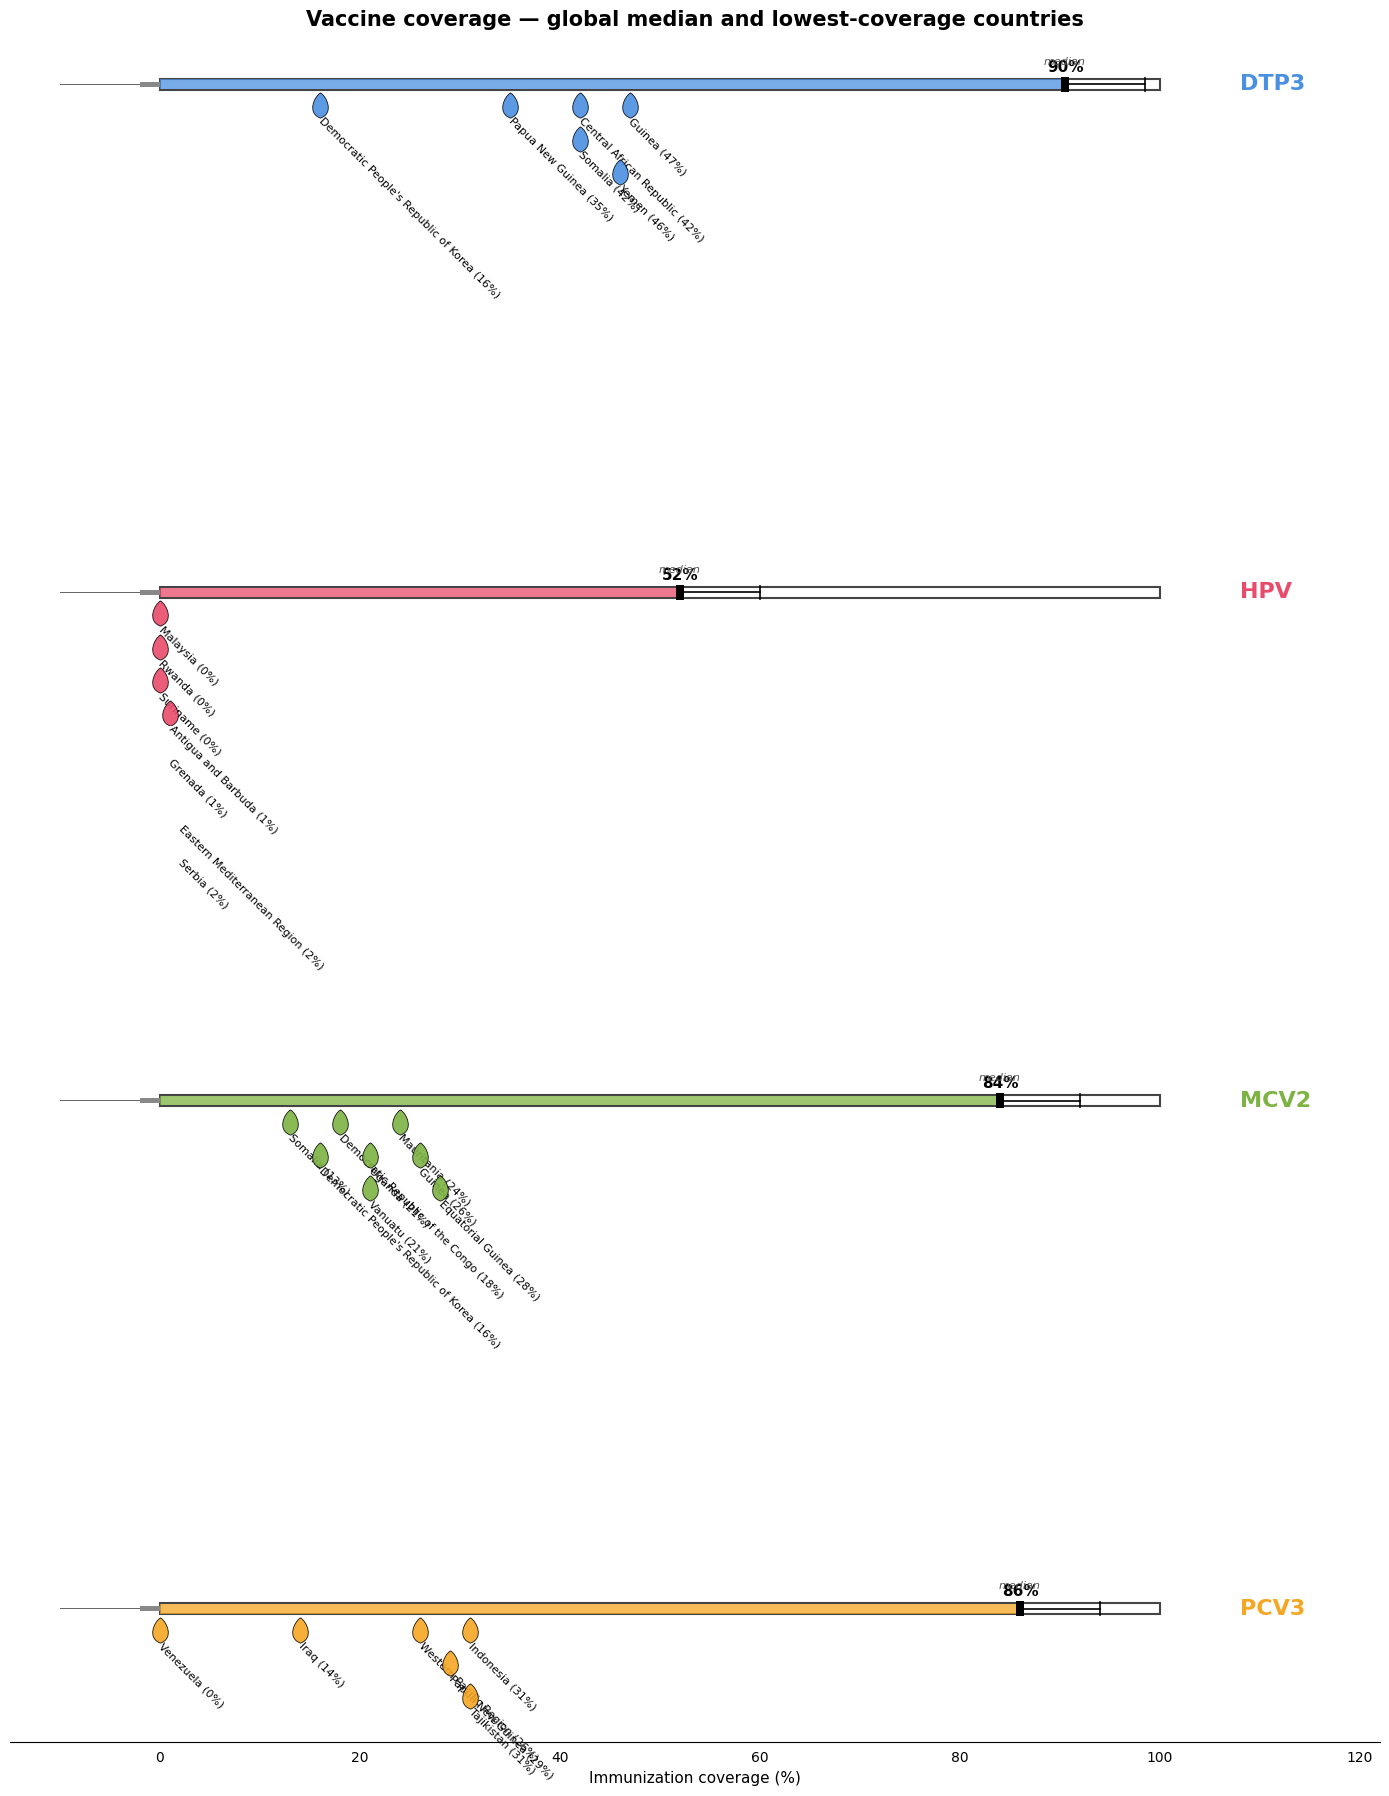

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import os

os.makedirs('Plot_pictures', exist_ok=True)

# Classic teardrop: pointed at top, round bulb at bottom
DROP = Path(
    [(0, 1.0),
     (0.5, 0.7), (1.1, -0.6), (0, -1.0),
     (-1.1, -0.6), (-0.5, 0.7), (0, 1.0)],
    [Path.MOVETO] + [Path.CURVE4]*6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
n_drops = {'DTP3': 6, 'HPV': 7, 'MCV2': 8, 'PCV3': 6}

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

for ax, vaccine, color in zip(axes, order, colors):
    sub = vaccine_df[vaccine_df['Vaccine'] == vaccine].dropna(subset=['NumericValue'])
    median = sub['NumericValue'].median()
    bottom_n = (sub.nsmallest(n_drops[vaccine], 'NumericValue')
                .sort_values('NumericValue').reset_index(drop=True))

    barrel_h = 0.5
    by = 0
    needle_tip_x = -10

    # Needle
    ax.add_patch(patches.Polygon(
        [[needle_tip_x, by + 0.03], [-2, by + 0.03],
         [-2, by - 0.03], [needle_tip_x, by - 0.03]],
        facecolor='#666', zorder=3))
    ax.add_patch(patches.Rectangle((-2, by - 0.12), 2, 0.24,
                                   facecolor='#888', zorder=3))
    # Barrel + fill
    ax.add_patch(patches.Rectangle((0, by - barrel_h/2), 100, barrel_h,
                                   linewidth=1.5, edgecolor='#444',
                                   facecolor='white', zorder=2))
    ax.add_patch(patches.Rectangle((0, by - barrel_h/2 + 0.03), median, barrel_h - 0.06,
                                   facecolor=color, alpha=0.75, zorder=2.5))
    # Plunger (median bar + narrow lines)
    ax.add_patch(patches.Rectangle((median - 0.4, by - barrel_h/2 - 0.08),
                                   0.8, barrel_h + 0.16,
                                   facecolor='black', zorder=4))
    ax.plot([median + 0.4, median + 8.0], [by, by],
            color='black', lw=1.2, zorder=4)
    ax.plot([median + 8.0, median + 8.0],
            [by - barrel_h/2 - 0.05, by + barrel_h/2 + 0.05],
            color='black', lw=1.2, zorder=4)
    # Median label
    ax.text(median, by + barrel_h/2 + 0.18, f'{median:.0f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
    ax.text(median, by + barrel_h/2 + 0.55, 'median',
            ha='center', va='bottom', fontsize=8, color='#555', style='italic')

    # Drops placed at x = value; stack vertically if values collide
    base_y = by - barrel_h/2 - 0.7
    positions = []
    for _, row in bottom_n.iterrows():
        x = row['NumericValue']
        drop_y = base_y
        while any(abs(x - px) < 5 and abs(drop_y - py) < 1.5 for px, py in positions):
            drop_y -= 1.5
        positions.append((x, drop_y))

        ax.scatter(x, drop_y, s=400, marker=DROP, color=color, alpha=0.9,
                   edgecolor='black', linewidth=0.6, zorder=5)
        ax.text(x - 0.3, drop_y - 0.5,
                f"{row['LocationShort']} ({row['NumericValue']:.0f}%)",
                rotation=-45, ha='left', va='top', fontsize=8)

    # Vaccine name
    ax.text(108, by, vaccine, fontsize=16, fontweight='bold',
            va='center', ha='left', color=color)

    ax.set_xlim(-15, 122)
    ax.set_ylim(-6.0, 1.5)
    ax.set_yticks([])
    for s in ['left', 'right', 'top']:
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False)

axes[-1].tick_params(labelbottom=True)
axes[-1].spines['bottom'].set_visible(True)
axes[-1].set_xlabel('Immunization coverage (%)', fontsize=11)

fig.suptitle('Vaccine coverage — global median and lowest-coverage countries',
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_syringes.png', dpi=300, bbox_inches='tight')
plt.show()
                       


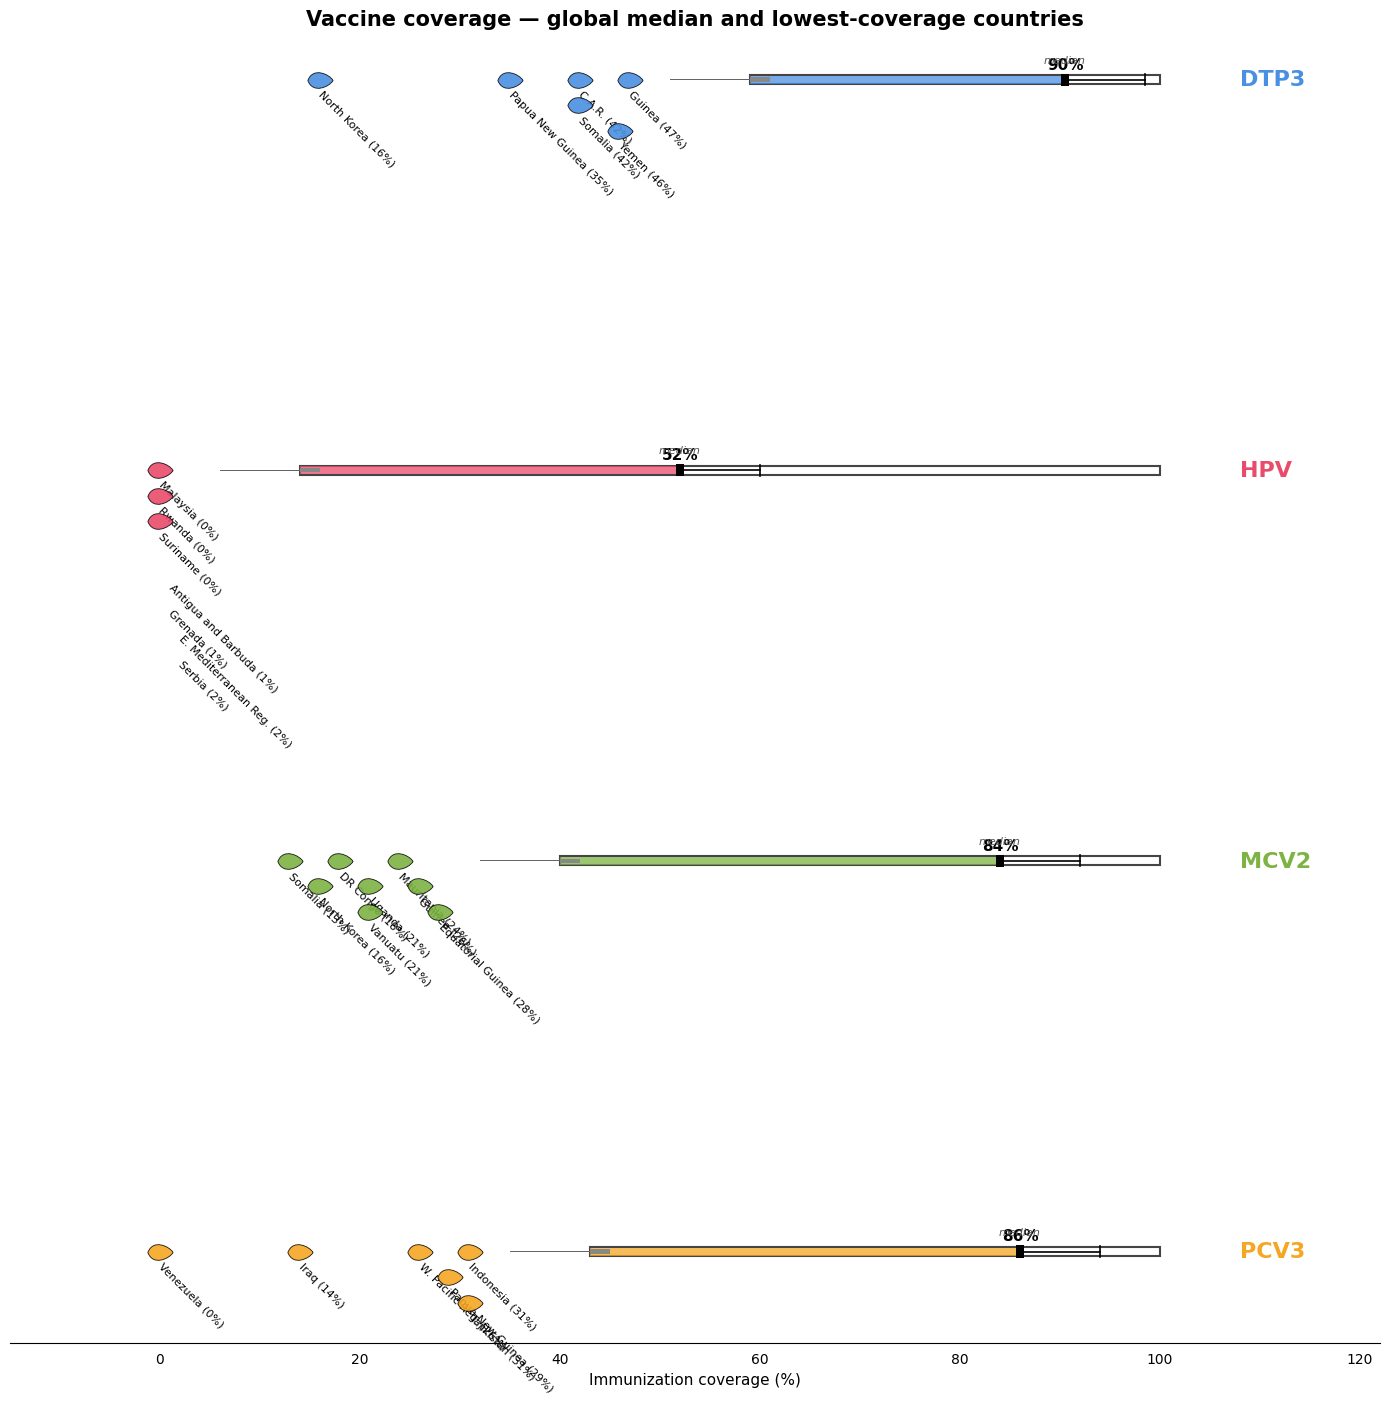

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import os

os.makedirs('Plot_pictures', exist_ok=True)

# Teardrop rotated 90° CW (tip points right, toward the syringe)
DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4]*6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
n_drops = {'DTP3': 6, 'HPV': 7, 'MCV2': 8, 'PCV3': 6}

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

for ax, vaccine, color in zip(axes, order, colors):
    sub = vaccine_df[vaccine_df['Vaccine'] == vaccine].dropna(subset=['NumericValue'])
    median = sub['NumericValue'].median()
    bottom_n = (sub.nsmallest(n_drops[vaccine], 'NumericValue')
                .sort_values('NumericValue').reset_index(drop=True))
    max_bottom = bottom_n['NumericValue'].max()

    barrel_h = 0.5
    by = 0
    # Syringe placed to the right of the worst-performer drops
    needle_tip_x = max_bottom + 4
    barrel_left = needle_tip_x + 8
    barrel_right = 100
    barrel_width = barrel_right - barrel_left

    # --- Needle ---
    ax.add_patch(patches.Polygon(
        [[needle_tip_x, by + 0.03], [barrel_left, by + 0.03],
         [barrel_left, by - 0.03], [needle_tip_x, by - 0.03]],
        facecolor='#666', zorder=3))
    ax.add_patch(patches.Rectangle((barrel_left, by - 0.12), 2, 0.24,
                                   facecolor='#888', zorder=3))

    # --- Barrel ---
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2), barrel_width, barrel_h,
                                   linewidth=1.5, edgecolor='#444',
                                   facecolor='white', zorder=2))
    fill_width = max(0, median - barrel_left)
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2 + 0.03),
                                   fill_width, barrel_h - 0.06,
                                   facecolor=color, alpha=0.75, zorder=2.5))

    # --- Plunger: median bar + narrow lines for rod & thumb ---
    ax.add_patch(patches.Rectangle((median - 0.4, by - barrel_h/2 - 0.08),
                                   0.8, barrel_h + 0.16,
                                   facecolor='black', zorder=4))
    ax.plot([median + 0.4, median + 8.0], [by, by],
            color='black', lw=1.2, zorder=4)
    ax.plot([median + 8.0, median + 8.0],
            [by - barrel_h/2 - 0.05, by + barrel_h/2 + 0.05],
            color='black', lw=1.2, zorder=4)

    # --- Median label ---
    ax.text(median, by + barrel_h/2 + 0.18, f'{median:.0f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
    ax.text(median, by + barrel_h/2 + 0.55, 'median',
            ha='center', va='bottom', fontsize=8, color='#555', style='italic')

    # --- Drops at x = country's value, stacked when colliding ---
    positions = []
    for _, row in bottom_n.iterrows():
        x = row['NumericValue']
        drop_y = by
        while any(abs(x - px) < 5 and abs(drop_y - py) < 1.4 for px, py in positions):
            drop_y -= 1.4
        positions.append((x, drop_y))

        ax.scatter(x, drop_y, s=400, marker=DROP, color=color, alpha=0.9,
                   edgecolor='black', linewidth=0.6, zorder=5)
        ax.text(x - 0.3, drop_y - 0.5,
                f"{row['LocationShort']} ({row['NumericValue']:.0f}%)",
                rotation=-45, ha='left', va='top', fontsize=8)

    # --- Vaccine name on the right ---
    ax.text(108, by, vaccine, fontsize=16, fontweight='bold',
            va='center', ha='left', color=color)

    ax.set_xlim(-15, 122)
    ax.set_ylim(-5.0, 1.5)
    ax.set_yticks([])
    for s in ['left', 'right', 'top']:
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False)

axes[-1].tick_params(labelbottom=True)
axes[-1].spines['bottom'].set_visible(True)
axes[-1].set_xlabel('Immunization coverage (%)', fontsize=11)

fig.suptitle('Vaccine coverage — global median and lowest-coverage countries',
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_syringes.png', dpi=300, bbox_inches='tight')
plt.show()

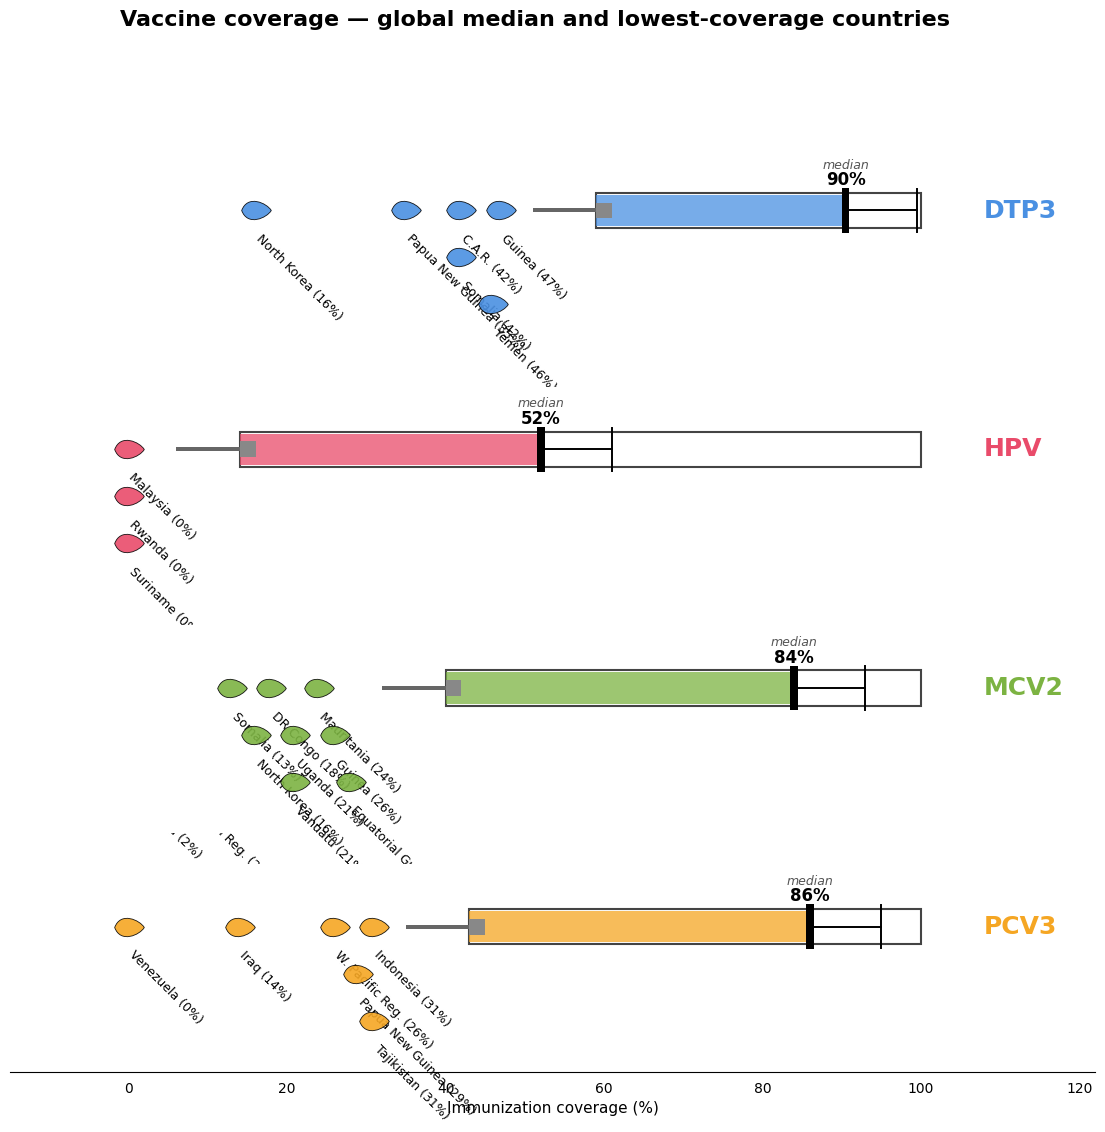

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4]*6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
n_drops = {'DTP3': 6, 'HPV': 7, 'MCV2': 8, 'PCV3': 6}

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True,
                         gridspec_kw={'hspace': 0.15})

for ax, vaccine, color in zip(axes, order, colors):
    sub = vaccine_df[vaccine_df['Vaccine'] == vaccine].dropna(subset=['NumericValue'])
    median = sub['NumericValue'].median()
    bottom_n = (sub.nsmallest(n_drops[vaccine], 'NumericValue')
                .sort_values('NumericValue').reset_index(drop=True))
    max_bottom = bottom_n['NumericValue'].max()

    barrel_h = 0.9       # bigger syringe (was 0.5)
    by = 0
    needle_tip_x = max_bottom + 4
    barrel_left = needle_tip_x + 8
    barrel_right = 100
    barrel_width = barrel_right - barrel_left

    # Needle (thicker)
    ax.add_patch(patches.Polygon(
        [[needle_tip_x, by + 0.05], [barrel_left, by + 0.05],
         [barrel_left, by - 0.05], [needle_tip_x, by - 0.05]],
        facecolor='#666', zorder=3))
    ax.add_patch(patches.Rectangle((barrel_left, by - 0.20), 2, 0.40,
                                   facecolor='#888', zorder=3))

    # Barrel
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2), barrel_width, barrel_h,
                                   linewidth=1.5, edgecolor='#444',
                                   facecolor='white', zorder=2))
    fill_width = max(0, median - barrel_left)
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2 + 0.05),
                                   fill_width, barrel_h - 0.10,
                                   facecolor=color, alpha=0.75, zorder=2.5))

    # Plunger
    ax.add_patch(patches.Rectangle((median - 0.5, by - barrel_h/2 - 0.12),
                                   1.0, barrel_h + 0.24,
                                   facecolor='black', zorder=4))
    ax.plot([median + 0.5, median + 9.0], [by, by],
            color='black', lw=1.4, zorder=4)
    ax.plot([median + 9.0, median + 9.0],
            [by - barrel_h/2 - 0.10, by + barrel_h/2 + 0.10],
            color='black', lw=1.4, zorder=4)

    # Median label
    ax.text(median, by + barrel_h/2 + 0.10, f'{median:.0f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
    ax.text(median, by + barrel_h/2 + 0.55, 'median',
            ha='center', va='bottom', fontsize=9, color='#555', style='italic')

    # Drops, stacked when colliding
    positions = []
    for _, row in bottom_n.iterrows():
        x = row['NumericValue']
        drop_y = by
        while any(abs(x - px) < 5 and abs(drop_y - py) < 1.2 for px, py in positions):
            drop_y -= 1.2
        positions.append((x, drop_y))

        ax.scatter(x, drop_y, s=550, marker=DROP, color=color, alpha=0.9,
                   edgecolor='black', linewidth=0.6, zorder=5)
        ax.text(x - 0.3, drop_y - 0.55,
                f"{row['LocationShort']} ({row['NumericValue']:.0f}%)",
                rotation=-45, ha='left', va='top', fontsize=9)

    # Vaccine label on the right
    ax.text(108, by, vaccine, fontsize=18, fontweight='bold',
            va='center', ha='left', color=color)

    ax.set_xlim(-15, 122)
    ax.set_ylim(-3.7, 1.6)
    ax.set_yticks([])
    for s in ['left', 'right', 'top']:
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False)

axes[-1].tick_params(labelbottom=True)
axes[-1].spines['bottom'].set_visible(True)
axes[-1].set_xlabel('Immunization coverage (%)', fontsize=11)

fig.suptitle('Vaccine coverage — global median and lowest-coverage countries',
             fontsize=16, fontweight='bold', y=0.995)

plt.subplots_adjust(hspace=0.15)
plt.savefig('Plot_pictures/vaccine_syringes.png', dpi=300, bbox_inches='tight')
plt.show()

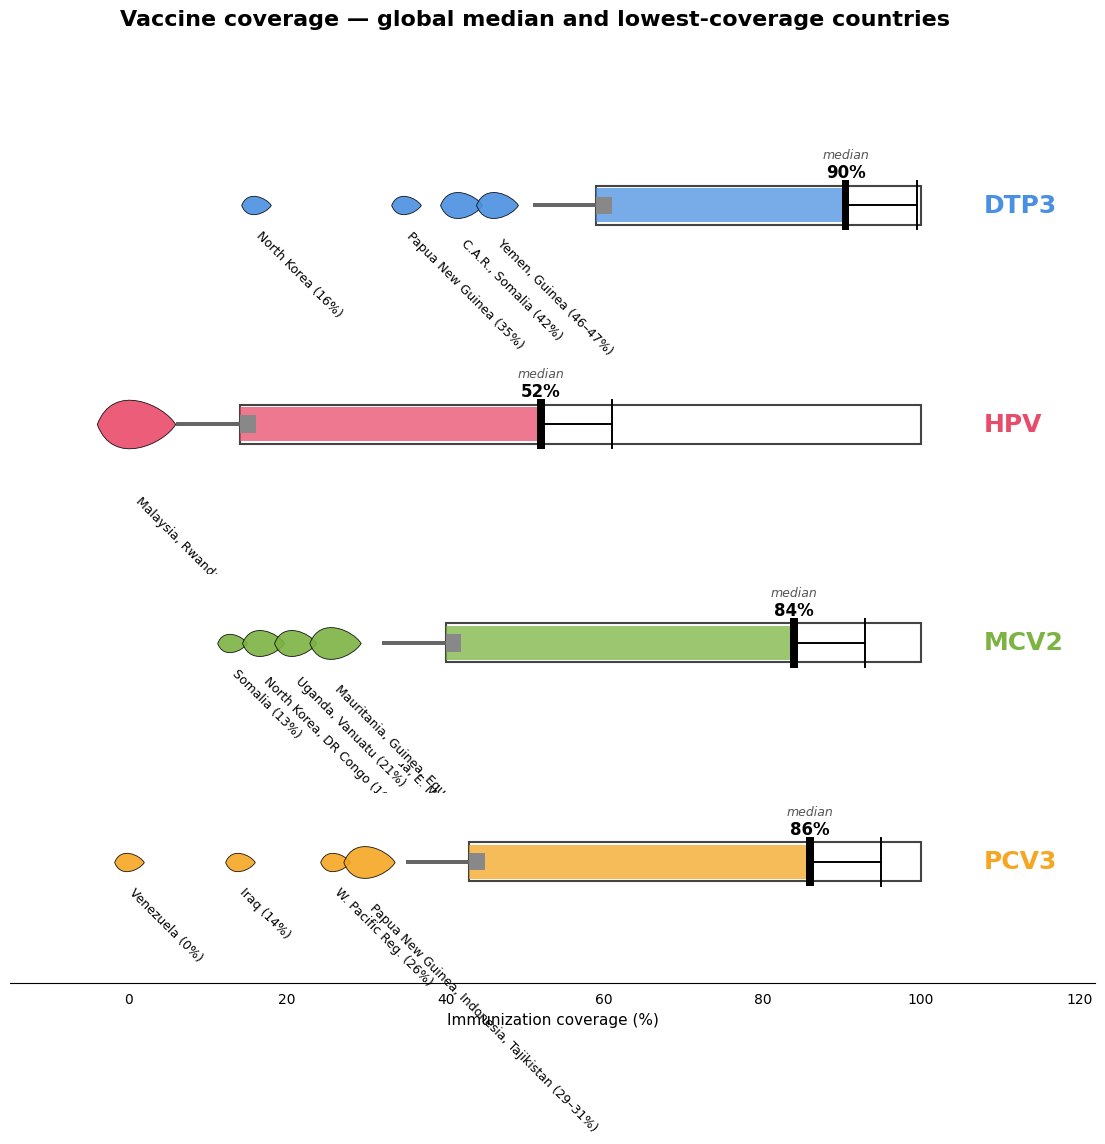

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4]*6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
n_drops = {'DTP3': 6, 'HPV': 7, 'MCV2': 8, 'PCV3': 6}
GROUP_THRESHOLD = 2          # % within which countries merge into one drop
BASE_DROP_SIZE = 550         # size of a single-country drop; merged = base × count

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={'hspace': 0.15})

for ax, vaccine, color in zip(axes, order, colors):
    sub = vaccine_df[vaccine_df['Vaccine'] == vaccine].dropna(subset=['NumericValue'])
    median = sub['NumericValue'].median()
    bottom_n = (sub.nsmallest(n_drops[vaccine], 'NumericValue')
                .sort_values('NumericValue').reset_index(drop=True))
    max_bottom = bottom_n['NumericValue'].max()

    barrel_h = 0.9
    by = 0
    needle_tip_x = max_bottom + 4
    barrel_left = needle_tip_x + 8
    barrel_right = 100
    barrel_width = barrel_right - barrel_left

    # Needle
    ax.add_patch(patches.Polygon(
        [[needle_tip_x, by + 0.05], [barrel_left, by + 0.05],
         [barrel_left, by - 0.05], [needle_tip_x, by - 0.05]],
        facecolor='#666', zorder=3))
    ax.add_patch(patches.Rectangle((barrel_left, by - 0.20), 2, 0.40,
                                   facecolor='#888', zorder=3))
    # Barrel
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2), barrel_width, barrel_h,
                                   linewidth=1.5, edgecolor='#444',
                                   facecolor='white', zorder=2))
    fill_width = max(0, median - barrel_left)
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2 + 0.05),
                                   fill_width, barrel_h - 0.10,
                                   facecolor=color, alpha=0.75, zorder=2.5))
    # Plunger
    ax.add_patch(patches.Rectangle((median - 0.5, by - barrel_h/2 - 0.12),
                                   1.0, barrel_h + 0.24,
                                   facecolor='black', zorder=4))
    ax.plot([median + 0.5, median + 9.0], [by, by],
            color='black', lw=1.4, zorder=4)
    ax.plot([median + 9.0, median + 9.0],
            [by - barrel_h/2 - 0.10, by + barrel_h/2 + 0.10],
            color='black', lw=1.4, zorder=4)
    # Median label
    ax.text(median, by + barrel_h/2 + 0.10, f'{median:.0f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
    ax.text(median, by + barrel_h/2 + 0.55, 'median',
            ha='center', va='bottom', fontsize=9, color='#555', style='italic')

    # --- Build groups of close-valued countries ---
    groups = []
    current = [bottom_n.iloc[0]]
    for i in range(1, len(bottom_n)):
        row = bottom_n.iloc[i]
        if row['NumericValue'] - current[-1]['NumericValue'] <= GROUP_THRESHOLD:
            current.append(row)
        else:
            groups.append(current)
            current = [row]
    groups.append(current)

    # --- Draw one drop per group, sized by group count ---
    for grp in groups:
        n = len(grp)
        x = sum(r['NumericValue'] for r in grp) / n
        drop_y = by
        size = BASE_DROP_SIZE * n   # area = count × base

        ax.scatter(x, drop_y, s=size, marker=DROP, color=color, alpha=0.9,
                   edgecolor='black', linewidth=0.6, zorder=5)

        names = ", ".join(r['LocationShort'] for r in grp)
        vals = [r['NumericValue'] for r in grp]
        val_str = (f"{vals[0]:.0f}%" if min(vals) == max(vals)
                   else f"{min(vals):.0f}–{max(vals):.0f}%")
        label = f"{names} ({val_str})"

        # Bigger drops need a bit more clearance below
        offset = 0.55 + 0.18 * (n - 1)
        ax.text(x - 0.3, drop_y - offset, label,
                rotation=-45, ha='left', va='top', fontsize=9)

    ax.text(108, by, vaccine, fontsize=18, fontweight='bold',
            va='center', ha='left', color=color)
    ax.set_xlim(-15, 122)
    ax.set_ylim(-2.8, 1.6)
    ax.set_yticks([])
    for s in ['left', 'right', 'top']:
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False)

axes[-1].tick_params(labelbottom=True)
axes[-1].spines['bottom'].set_visible(True)
axes[-1].set_xlabel('Immunization coverage (%)', fontsize=11)

fig.suptitle('Vaccine coverage — global median and lowest-coverage countries',
             fontsize=16, fontweight='bold', y=0.995)

plt.subplots_adjust(hspace=0.15)
plt.savefig('Plot_pictures/vaccine_syringes.png', dpi=300, bbox_inches='tight')
plt.show()

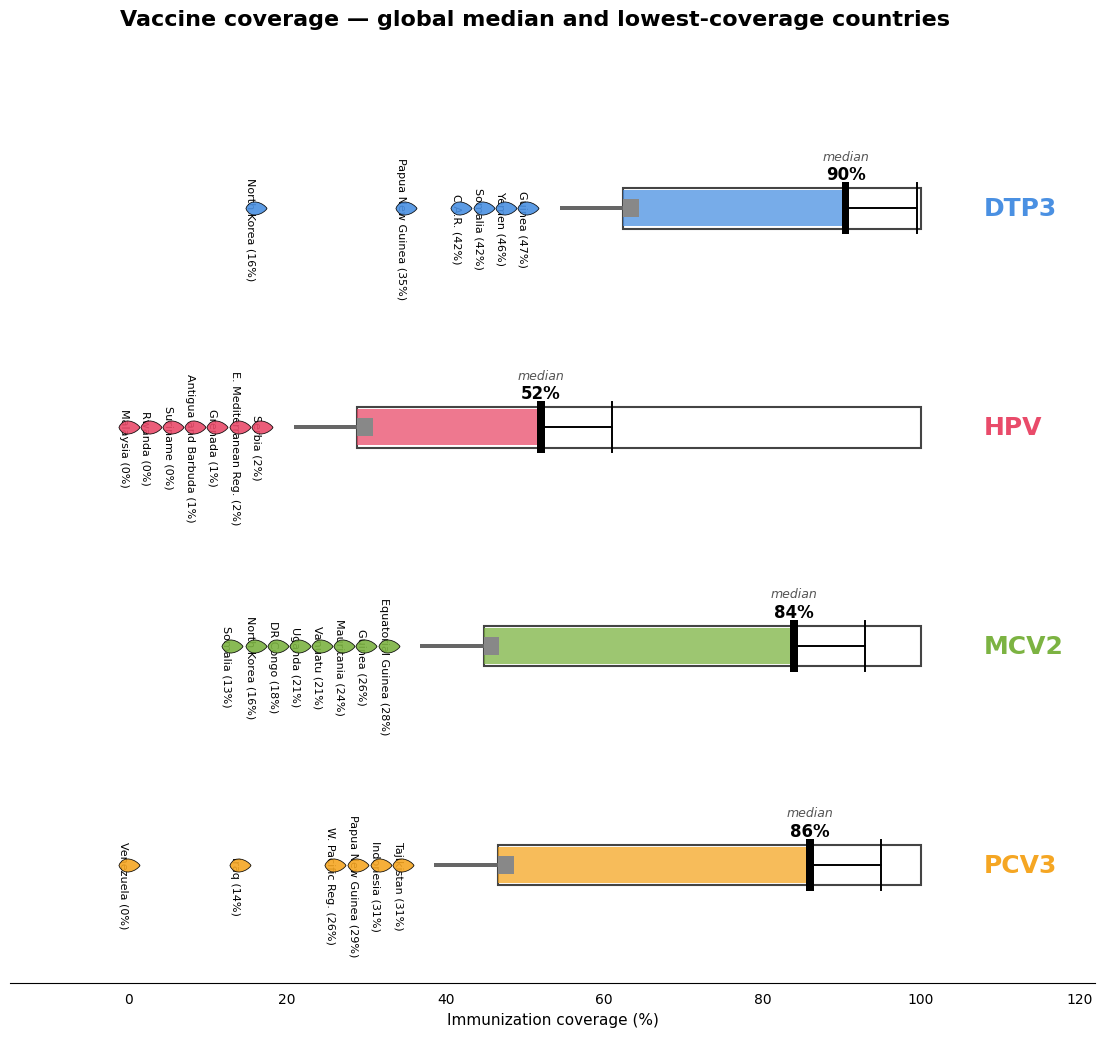

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4]*6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
n_drops = {'DTP3': 6, 'HPV': 7, 'MCV2': 8, 'PCV3': 6}
DROP_SIZE = 280     # uniform, smaller drops
MIN_SPACING = 2.8   # min x-gap between drops; ties get nudged right

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={'hspace': 0.15})

for ax, vaccine, color in zip(axes, order, colors):
    sub = vaccine_df[vaccine_df['Vaccine'] == vaccine].dropna(subset=['NumericValue'])
    median = sub['NumericValue'].median()
    bottom_n = (sub.nsmallest(n_drops[vaccine], 'NumericValue')
                .sort_values('NumericValue').reset_index(drop=True))

    # Place drops at value, but enforce minimum spacing for ties / near-ties
    xs = []
    prev_x = -1000
    for _, row in bottom_n.iterrows():
        x = row['NumericValue']
        if x - prev_x < MIN_SPACING:
            x = prev_x + MIN_SPACING
        xs.append(x)
        prev_x = x
    max_drop_x = max(xs)

    barrel_h = 0.9
    by = 0
    needle_tip_x = max_drop_x + 4
    barrel_left = needle_tip_x + 8
    barrel_right = 100
    barrel_width = barrel_right - barrel_left

    # Needle
    ax.add_patch(patches.Polygon(
        [[needle_tip_x, by + 0.05], [barrel_left, by + 0.05],
         [barrel_left, by - 0.05], [needle_tip_x, by - 0.05]],
        facecolor='#666', zorder=3))
    ax.add_patch(patches.Rectangle((barrel_left, by - 0.20), 2, 0.40,
                                   facecolor='#888', zorder=3))
    # Barrel + fill
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2), barrel_width, barrel_h,
                                   linewidth=1.5, edgecolor='#444',
                                   facecolor='white', zorder=2))
    fill_width = max(0, median - barrel_left)
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2 + 0.05),
                                   fill_width, barrel_h - 0.10,
                                   facecolor=color, alpha=0.75, zorder=2.5))
    # Plunger
    ax.add_patch(patches.Rectangle((median - 0.5, by - barrel_h/2 - 0.12),
                                   1.0, barrel_h + 0.24,
                                   facecolor='black', zorder=4))
    ax.plot([median + 0.5, median + 9.0], [by, by],
            color='black', lw=1.4, zorder=4)
    ax.plot([median + 9.0, median + 9.0],
            [by - barrel_h/2 - 0.10, by + barrel_h/2 + 0.10],
            color='black', lw=1.4, zorder=4)
    # Median label
    ax.text(median, by + barrel_h/2 + 0.10, f'{median:.0f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
    ax.text(median, by + barrel_h/2 + 0.55, 'median',
            ha='center', va='bottom', fontsize=9, color='#555', style='italic')

    # All drops on one line, same size, vertical labels
    for x, (_, row) in zip(xs, bottom_n.iterrows()):
        ax.scatter(x, by, s=DROP_SIZE, marker=DROP, color=color, alpha=0.9,
                   edgecolor='black', linewidth=0.6, zorder=5)
        ax.text(x, by - 0.45,
                f"{row['LocationShort']} ({row['NumericValue']:.0f}%)",
                rotation=270, rotation_mode='anchor',
                ha='center', va='top', fontsize=8)

    ax.text(108, by, vaccine, fontsize=18, fontweight='bold',
            va='center', ha='left', color=color)
    ax.set_xlim(-15, 122)
    ax.set_ylim(-2.6, 1.6)
    ax.set_yticks([])
    for s in ['left', 'right', 'top']:
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False)

axes[-1].tick_params(labelbottom=True)
axes[-1].spines['bottom'].set_visible(True)
axes[-1].set_xlabel('Immunization coverage (%)', fontsize=11)

fig.suptitle('Vaccine coverage — global median and lowest-coverage countries',
             fontsize=16, fontweight='bold', y=0.995)

plt.subplots_adjust(hspace=0.15)
plt.savefig('Plot_pictures/vaccine_syringes.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4]*6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
n_drops = {'DTP3': 6, 'HPV': 7, 'MCV2': 8, 'PCV3': 6}
DROP_SIZE = 280
MIN_SPACING = 5     # wider gap so 45°-tilted labels don't run into each other

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={'hspace': 0.15})

for ax, vaccine, color in zip(axes, order, colors):
    sub = vaccine_df[vaccine_df['Vaccine'] == vaccine].dropna(subset=['NumericValue'])
    median = sub['NumericValue'].median()
    bottom_n = (sub.nsmallest(n_drops[vaccine], 'NumericValue')
                .sort_values('NumericValue').reset_index(drop=True))

    # Place drops at value, jitter ties / near-ties
    xs = []
    prev_x = -1000
    for _, row in bottom_n.iterrows():
        x = row['NumericValue']
        if x - prev_x < MIN_SPACING:
            x = prev_x + MIN_SPACING
        xs.append(x)
        prev_x = x
    max_drop_x = max(xs)

    barrel_h = 0.9
    by = 0
    needle_tip_x = max_drop_x + 4
    barrel_left = needle_tip_x + 8
    barrel_width = median - barrel_left          # barrel ends at the median

    # Needle
    ax.add_patch(patches.Polygon(
        [[needle_tip_x, by + 0.05], [barrel_left, by + 0.05],
         [barrel_left, by - 0.05], [needle_tip_x, by - 0.05]],
        facecolor='#666', zorder=3))
    ax.add_patch(patches.Rectangle((barrel_left, by - 0.20), 2, 0.40,
                                   facecolor='#888', zorder=3))

    # Filled barrel — single rectangle from left to median (no empty bar to 100)
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2),
                                   barrel_width, barrel_h,
                                   linewidth=1.5, edgecolor='#444',
                                   facecolor=color, alpha=0.75, zorder=2))

    # Plunger sits at median (right edge of barrel) + narrow rod & thumb
# inside the per-vaccine loop, replace the plunger block:

max_val = sub['NumericValue'].max()

# Plunger head at median (kept solid)
ax.add_patch(patches.Rectangle((median - 0.5, by - barrel_h/2 - 0.12),
                               1.0, barrel_h + 0.24,
                               facecolor='black', zorder=4))
# Rod stretches from median to max value
ax.plot([median + 0.5, max_val], [by, by],
        color='black', lw=1.4, zorder=4)
# Thumb sits at max value
ax.plot([max_val, max_val],
        [by - barrel_h/2 - 0.10, by + barrel_h/2 + 0.10],
        color='black', lw=1.4, zorder=4)

# Optional: label the max so the right end has a clear meaning
ax.text(max_val, by + barrel_h/2 + 0.10, f'{max_val:.0f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#555')
ax.text(max_val, by + barrel_h/2 + 0.55, 'max',
        ha='center', va='bottom', fontsize=9, color='#555', style='italic')

    # Median label
    ax.text(median, by + barrel_h/2 + 0.10, f'{median:.0f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
    ax.text(median, by + barrel_h/2 + 0.55, 'median',
            ha='center', va='bottom', fontsize=9, color='#555', style='italic')

    # Drops on one line, same size; labels under the drops at -45°
    for x, (_, row) in zip(xs, bottom_n.iterrows()):
        ax.scatter(x, by, s=DROP_SIZE, marker=DROP, color=color, alpha=0.9,
                   edgecolor='black', linewidth=0.6, zorder=5)
        ax.text(x, by - 0.75,
                f"{row['LocationShort']} ({row['NumericValue']:.0f}%)",
                rotation=-45, ha='left', va='top', fontsize=9)

    ax.text(108, by, vaccine, fontsize=18, fontweight='bold',
            va='center', ha='left', color=color)
    ax.set_xlim(-15, 122)
    ax.set_ylim(-3.0, 1.6)
    ax.set_yticks([])
    for s in ['left', 'right', 'top']:
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False)

axes[-1].tick_params(labelbottom=True)
axes[-1].spines['bottom'].set_visible(True)
axes[-1].set_xlabel('Immunization coverage (%)', fontsize=11)

fig.suptitle('Vaccine coverage — global median and lowest-coverage countries',
             fontsize=16, fontweight='bold', y=0.995)

plt.subplots_adjust(hspace=0.15)
plt.savefig('Plot_pictures/vaccine_syringes.png', dpi=300, bbox_inches='tight')
plt.show()

IndentationError: unexpected indent (154163533.py, line 84)

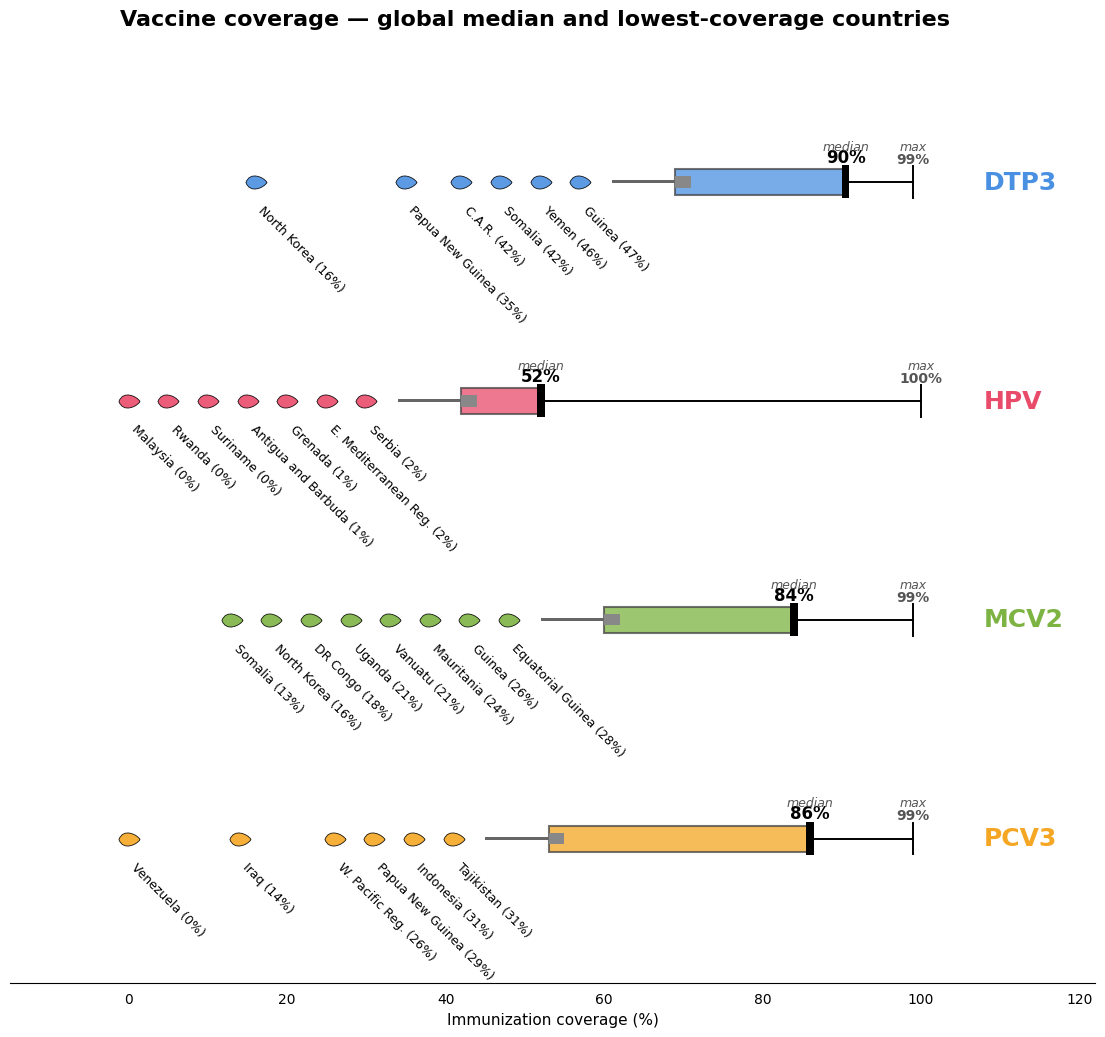

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4]*6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
n_drops = {'DTP3': 6, 'HPV': 7, 'MCV2': 8, 'PCV3': 6}
DROP_SIZE = 280
MIN_SPACING = 5

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={'hspace': 0.15})

for ax, vaccine, color in zip(axes, order, colors):
    sub = vaccine_df[vaccine_df['Vaccine'] == vaccine].dropna(subset=['NumericValue'])
    median = sub['NumericValue'].median()
    max_val = sub['NumericValue'].max()
    bottom_n = (sub.nsmallest(n_drops[vaccine], 'NumericValue')
                .sort_values('NumericValue').reset_index(drop=True))

    # Place drops at value, jitter ties / near-ties
    xs = []
    prev_x = -1000
    for _, row in bottom_n.iterrows():
        x = row['NumericValue']
        if x - prev_x < MIN_SPACING:
            x = prev_x + MIN_SPACING
        xs.append(x)
        prev_x = x
    max_drop_x = max(xs)

    barrel_h = 0.9
    by = 0
    needle_tip_x = max_drop_x + 4
    barrel_left = needle_tip_x + 8
    barrel_width = median - barrel_left          # barrel ends at the median

    # Needle
    ax.add_patch(patches.Polygon(
        [[needle_tip_x, by + 0.05], [barrel_left, by + 0.05],
         [barrel_left, by - 0.05], [needle_tip_x, by - 0.05]],
        facecolor='#666', zorder=3))
    ax.add_patch(patches.Rectangle((barrel_left, by - 0.20), 2, 0.40,
                                   facecolor='#888', zorder=3))

    # Filled barrel — single rectangle from left to median
    ax.add_patch(patches.Rectangle((barrel_left, by - barrel_h/2),
                                   barrel_width, barrel_h,
                                   linewidth=1.5, edgecolor='#444',
                                   facecolor=color, alpha=0.75, zorder=2))

    # --- Plunger: head at median, rod & thumb extend to max value ---
    ax.add_patch(patches.Rectangle((median - 0.5, by - barrel_h/2 - 0.12),
                                   1.0, barrel_h + 0.24,
                                   facecolor='black', zorder=4))
    ax.plot([median + 0.5, max_val], [by, by],
            color='black', lw=1.4, zorder=4)
    ax.plot([max_val, max_val],
            [by - barrel_h/2 - 0.10, by + barrel_h/2 + 0.10],
            color='black', lw=1.4, zorder=4)

    # Median label
    ax.text(median, by + barrel_h/2 + 0.10, f'{median:.0f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
    ax.text(median, by + barrel_h/2 + 0.55, 'median',
            ha='center', va='bottom', fontsize=9, color='#555', style='italic')

    # Max label (right end of plunger)
    ax.text(max_val, by + barrel_h/2 + 0.10, f'{max_val:.0f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#555')
    ax.text(max_val, by + barrel_h/2 + 0.55, 'max',
            ha='center', va='bottom', fontsize=9, color='#555', style='italic')

    # Drops on one line, same size; labels under the drops at -45°
    for x, (_, row) in zip(xs, bottom_n.iterrows()):
        ax.scatter(x, by, s=DROP_SIZE, marker=DROP, color=color, alpha=0.9,
                   edgecolor='black', linewidth=0.6, zorder=5)
        ax.text(x, by - 0.75,
                f"{row['LocationShort']} ({row['NumericValue']:.0f}%)",
                rotation=-45, ha='left', va='top', fontsize=9)

    ax.text(108, by, vaccine, fontsize=18, fontweight='bold',
            va='center', ha='left', color=color)
    ax.set_xlim(-15, 122)
    ax.set_ylim(-5, 1.6)
    ax.set_yticks([])
    for s in ['left', 'right', 'top']:
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False)

axes[-1].tick_params(labelbottom=True)
axes[-1].spines['bottom'].set_visible(True)
axes[-1].set_xlabel('Immunization coverage (%)', fontsize=11)

fig.suptitle('Vaccine coverage — global median and lowest-coverage countries',
             fontsize=16, fontweight='bold', y=0.995)

plt.subplots_adjust(hspace=0.15)
plt.savefig('Plot_pictures/vaccine_syringes.png', dpi=300, bbox_inches='tight')
plt.show()


SyntaxError: invalid character '—' (U+2014) (2517993947.py, line 4)

# beschreiben wie entschieden wurde, was tropfen werden


Vaccine coverage — global median and lowest-coverage countries

This figure visualizes WHO immunization-coverage data for four routine vaccines (DTP3, HPV, MCV2, PCV3) using a syringe metaphor. Each panel encodes the global distribution as a stylized syringe along an axis of coverage percentage (0–100 %).

The colored barrel of each syringe begins where the lowest-performing countries end and fills up to the global median coverage, which is marked by the solid black plunger and labelled above. The thin plunger rod then extends from the median to the maximum coverage observed in the dataset, indicating how much of the population is reached in the best-performing country.

Outside the needle, on the left of each syringe, a row of teardrop markers — tips pointed back toward the needle — shows the countries with the lowest coverage for that vaccine: six for DTP3 and PCV3, seven for HPV, and eight for MCV2. Each drop sits at the x-position corresponding to that country's coverage, with the country name and value annotated below at a 45° tilt.

The visualization makes two things visible at a glance: the overall reach of each vaccine, condensed into a single median–max range, and the specific countries that fall furthest behind it. The contrast is sharpest for HPV, where multiple countries report 0 % coverage of the primary target cohort — a gap of roughly 50 percentage points below the global median.

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\1932420058.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vaccine_df, x='Vaccine', y='NumericValue',


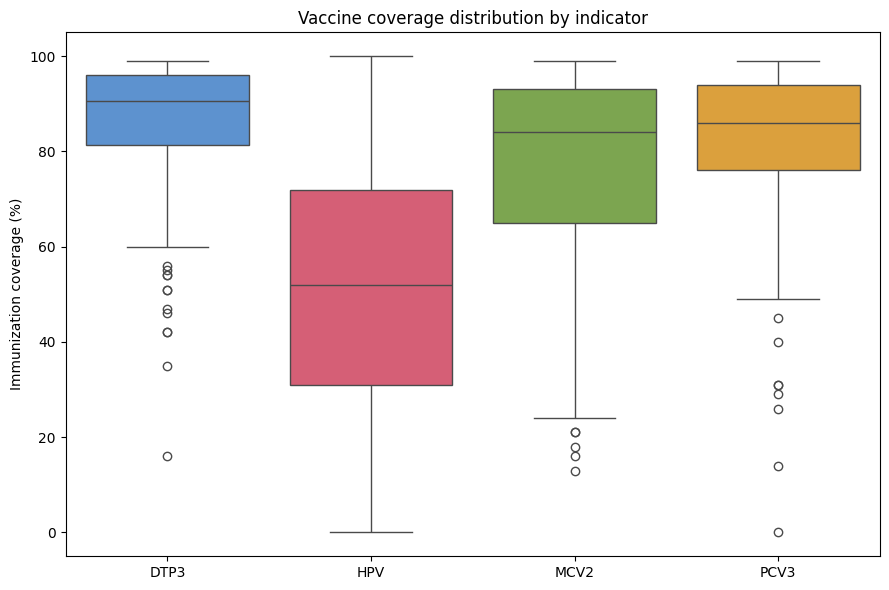

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('Plot_pictures', exist_ok=True)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']

plt.figure(figsize=(9, 6))
sns.boxplot(data=vaccine_df, x='Vaccine', y='NumericValue',
            order=order, palette=colors)

plt.ylabel('Immunization coverage (%)')
plt.xlabel('')
plt.title('Vaccine coverage distribution by indicator')
plt.ylim(-5, 105)
plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\3986713973.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=vaccine_df, y='Vaccine', x='NumericValue',


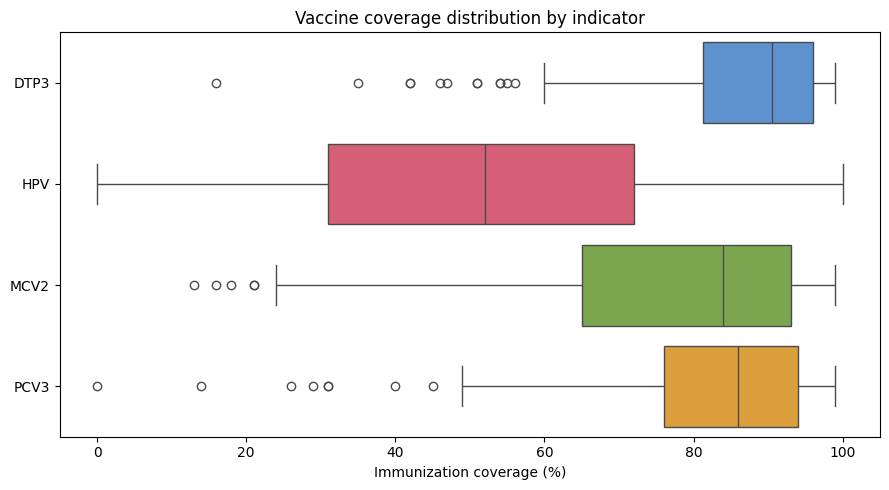

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('Plot_pictures', exist_ok=True)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']

plt.figure(figsize=(9, 5))
sns.boxplot(data=vaccine_df, y='Vaccine', x='NumericValue',
            order=order, palette=colors)

plt.xlabel('Immunization coverage (%)')
plt.ylabel('')
plt.title('Vaccine coverage distribution by indicator')
plt.xlim(-5, 105)
plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\1514176847.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


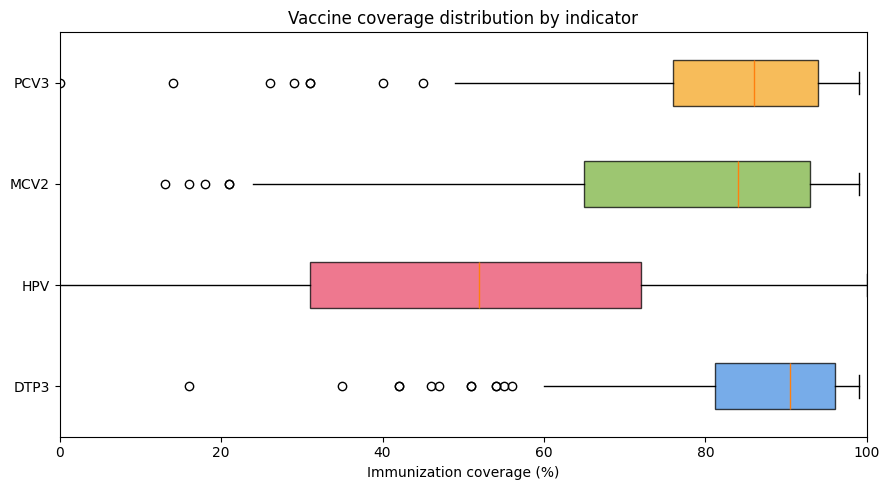

In [41]:
import matplotlib.pyplot as plt
import os

os.makedirs('Plot_pictures', exist_ok=True)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']

groups = [vaccine_df[vaccine_df['Vaccine'] == v]['NumericValue'].dropna().values
          for v in order]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

# Colour the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Hide the left-whisker cap on each box (every other cap, starting at index 0)
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(0, 100)
ax.set_title('Vaccine coverage distribution by indicator')
plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\1862884547.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


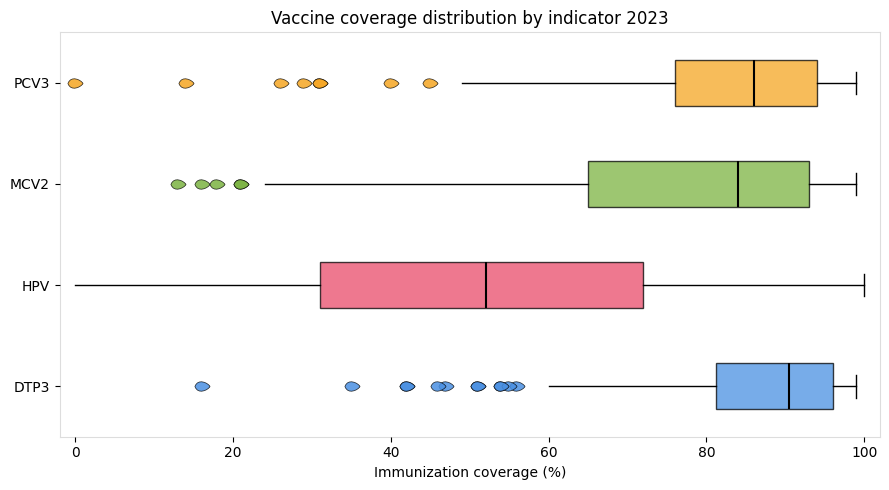

In [49]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
import os

os.makedirs('Plot_pictures', exist_ok=True)

# Teardrop pointing right (tip toward the boxplot)
DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']

groups = [vaccine_df[vaccine_df['Vaccine'] == v]['NumericValue'].dropna().values
          for v in order]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

# Colour the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Median lines black
for median_line in bp['medians']:
    median_line.set_color('black')
    median_line.set_linewidth(1.5)

# Hide the left-whisker cap on each box
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

# Outliers as teardrops, coloured per vaccine, tips pointing right toward the box
for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP)
    flier.set_markersize(12)
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5)
    flier.set_alpha(0.85)
    flier.set_linestyle('none')
# >>> NEW BLOCK: push all boxplot artists to the front <<<
for whisker in bp['whiskers']:
    whisker.set_zorder(3)
for cap in bp['caps']:
    cap.set_zorder(3)
for box in bp['boxes']:
    box.set_zorder(3)
for median in bp['medians']:
    median.set_zorder(4)
for flier in bp['fliers']:
    flier.set_zorder(4)
# >>> end new block <<<

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_title('Vaccine coverage distribution by indicator 2023')
# Spines in the background
for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)
    spine.set_zorder(0)
plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
import pandas as pd
import requests
import os

os.makedirs('CSV_files', exist_ok=True)

# 1) Grab the IndicatorName → IndicatorCode mapping from your existing data
codes = (vaccine_df[['IndicatorName', 'IndicatorCode']]
         .drop_duplicates()
         .set_index('IndicatorName')['IndicatorCode']
         .to_dict())
print("Indicator codes:", codes)

# 2) Same shortener you used for the 'Vaccine' column
def label(name):
    n = name.lower()
    if 'diphtheria' in n: return 'DTP3'
    if 'papillomavirus' in n: return 'HPV'
    if 'measles' in n: return 'MCV2'
    if 'pneumococcal' in n: return 'PCV3'

# 3) Fetch each indicator's full time series from the GHO API
all_rows = []
for name, code in codes.items():
    print(f"Fetching {code} ({label(name)})...")
    url = f"https://ghoapi.azureedge.net/api/{code}"
    data = requests.get(url).json()['value']
    df = pd.DataFrame(data)
    df['IndicatorName'] = name
    df['Vaccine'] = label(name)
    all_rows.append(df)

vaccine_all_years = pd.concat(all_rows, ignore_index=True)

# 4) Save to disk
out_path = 'CSV_files/vaccine_all_years.csv'
vaccine_all_years.to_csv(out_path, index=False)
print(f"Saved {len(vaccine_all_years):,} rows → {out_path}")
print(f"Years covered: {vaccine_all_years['TimeDim'].min()}–{vaccine_all_years['TimeDim'].max()}")
print(vaccine_all_years['Vaccine'].value_counts())

Indicator codes: {'Diphtheria-tetanus-pertussis (DTP3) immunization coverage among 1-year-olds (%)': 'WHS4_100', 'Human papillomavirus (HPV) immunization coverage estimates among primary target cohort (9-14 years old girls) (%': 'SDGHPVRECEIVED', 'Measles-containing-vaccine second-dose (MCV2) immunization coverage by the locally recommended age (%)': 'MCV2', 'Pneumococcal conjugate 3rd dose (PCV3) immunization coverage  among 1-year olds (%)': 'PCV3'}
Fetching WHS4_100 (DTP3)...
Fetching SDGHPVRECEIVED (HPV)...
Fetching MCV2 (MCV2)...
Fetching PCV3 (PCV3)...
Saved 14,988 rows → CSV_files/vaccine_all_years.csv
Years covered: 2000–2024
Vaccine
DTP3    5106
MCV2    5106
PCV3    3482
HPV     1294
Name: count, dtype: int64


In [50]:
# Country-level rows only (exclude regional/global aggregates)
countries_only = vaccine_all_years[vaccine_all_years['SpatialDimType'] == 'COUNTRY'].copy()

# Make sure values are numeric
countries_only['NumericValue'] = pd.to_numeric(countries_only['NumericValue'], errors='coerce')

# Median per year per vaccine
medians = (countries_only
           .dropna(subset=['NumericValue'])
           .groupby(['Vaccine', 'TimeDim'])['NumericValue']
           .median()
           .reset_index()
           .rename(columns={'TimeDim': 'Year', 'NumericValue': 'Median'})
           .sort_values(['Vaccine', 'Year'])
           .reset_index(drop=True))

print(medians)
medians.to_csv('CSV_files/vaccine_medians_by_year.csv', index=False)

   Vaccine  Year  Median
0     DTP3  2000    90.0
1     DTP3  2001    91.0
2     DTP3  2002    91.0
3     DTP3  2003    92.0
4     DTP3  2004    91.5
..     ...   ...     ...
77    PCV3  2020    82.0
78    PCV3  2021    79.0
79    PCV3  2022    83.0
80    PCV3  2023    83.0
81    PCV3  2024    85.0

[82 rows x 3 columns]


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\670554948.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


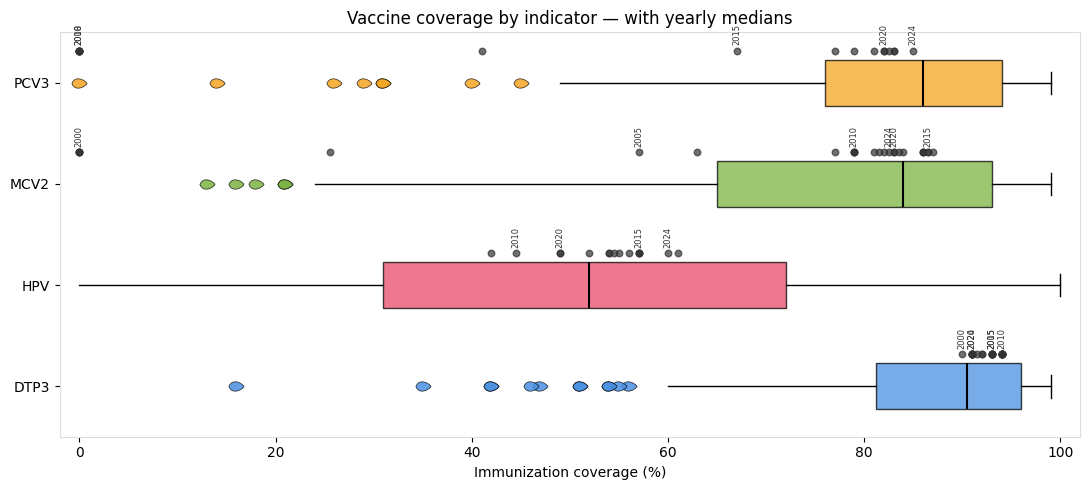

In [51]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']

groups = [vaccine_df[vaccine_df['Vaccine'] == v]['NumericValue'].dropna().values
          for v in order]

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

# Colour the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Median lines black
for median_line in bp['medians']:
    median_line.set_color('black')
    median_line.set_linewidth(1.5)

# Hide the left-whisker cap on each box
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

# Outliers as teardrops
for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP)
    flier.set_markersize(12)
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5)
    flier.set_alpha(0.85)
    flier.set_linestyle('none')

# Boxplot artists in front
for w in bp['whiskers']: w.set_zorder(3)
for c in bp['caps']:     c.set_zorder(3)
for b in bp['boxes']:    b.set_zorder(3)
for m in bp['medians']:  m.set_zorder(4)
for f in bp['fliers']:   f.set_zorder(4)

# --- Yearly medians for each vaccine, drawn above the box -------------
for i, vaccine in enumerate(order):
    y_pos = i + 1                        # boxplot uses 1-indexed positions
    vm = (medians[medians['Vaccine'] == vaccine]
          .sort_values('Year')
          .reset_index(drop=True))
    if vm.empty:
        continue

    years = vm['Year'].values
    vals  = vm['Median'].values
    dot_y = y_pos + 0.32

    ax.scatter(vals, [dot_y] * len(vals),
               s=22, color='#333', alpha=0.7, zorder=6)

    # Annotate every 5 years + first + last
    label_years = set(y for y in years if y % 5 == 0)
    label_years.update([years[0], years[-1]])
    for year, val in zip(years, vals):
        if year in label_years:
            ax.annotate(str(year), (val, dot_y + 0.05),
                        ha='center', va='bottom', fontsize=6,
                        rotation=90, color='#333')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_title('Vaccine coverage by indicator — with yearly medians')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_boxplot_yearly_medians.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\3901348303.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


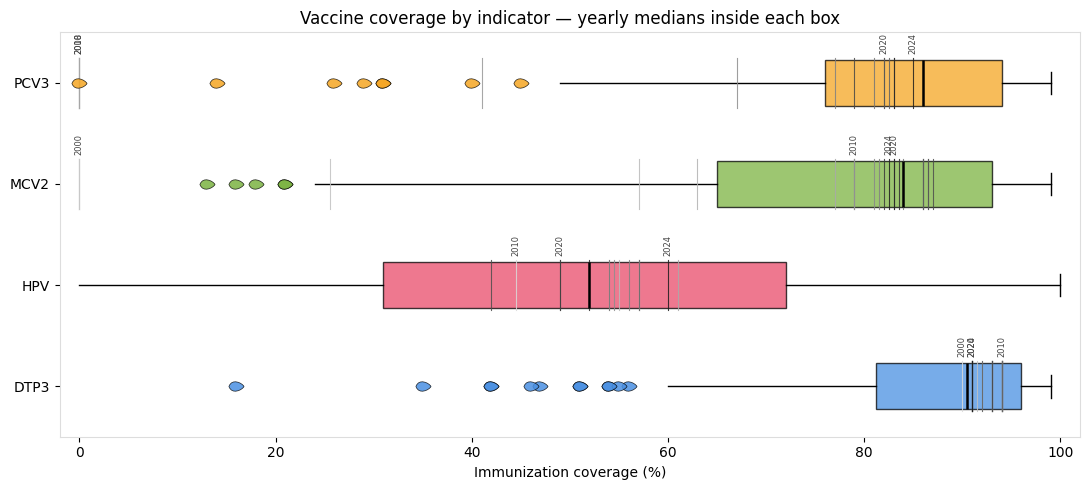

In [52]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
import numpy as np
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']

groups = [vaccine_df[vaccine_df['Vaccine'] == v]['NumericValue'].dropna().values
          for v in order]

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

# Colour the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Median lines black
for median_line in bp['medians']:
    median_line.set_color('black')
    median_line.set_linewidth(1.8)

# Hide the left-whisker cap
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

# Outliers as teardrops
for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP)
    flier.set_markersize(12)
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5)
    flier.set_alpha(0.85)
    flier.set_linestyle('none')

# zorder so artists sit above the spine
for w in bp['whiskers']: w.set_zorder(3)
for c in bp['caps']:     c.set_zorder(3)
for b in bp['boxes']:    b.set_zorder(3)
for m in bp['medians']:  m.set_zorder(5)     # bold median on top
for f in bp['fliers']:   f.set_zorder(4)

# --- Yearly medians as thin lines INSIDE each box --------------------
BOX_HALF = 0.25     # box height / 2
for i, vaccine in enumerate(order):
    y_pos = i + 1
    vm = (medians[medians['Vaccine'] == vaccine]
          .sort_values('Year').reset_index(drop=True))
    if vm.empty:
        continue

    years = vm['Year'].values
    vals  = vm['Median'].values

    # older year → lighter grey, newer → darker
    norm = plt.Normalize(years.min(), years.max())
    line_colors = plt.cm.Greys(0.25 + 0.65 * norm(years))

    for year, val, lc in zip(years, vals, line_colors):
        ax.plot([val, val], [y_pos - BOX_HALF, y_pos + BOX_HALF],
                color=lc, linewidth=0.8, alpha=0.85, zorder=3.5)

    # Label every 10th year + first + last
    to_label = {y for y in years if y % 10 == 0}
    to_label.update([years[0], years[-1]])
    for year, val in zip(years, vals):
        if year in to_label:
            ax.annotate(str(year), (val, y_pos + BOX_HALF + 0.04),
                        ha='center', va='bottom', fontsize=6,
                        rotation=90, color='#444')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_title('Vaccine coverage by indicator — yearly medians inside each box')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_boxplot_yearly_medians.png',
            dpi=300, bbox_inches='tight')
plt.show()

Country records available for 2024:
Vaccine
DTP3    194
MCV2    194
PCV3    194
HPV     140
Name: count, dtype: int64


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\252675545.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


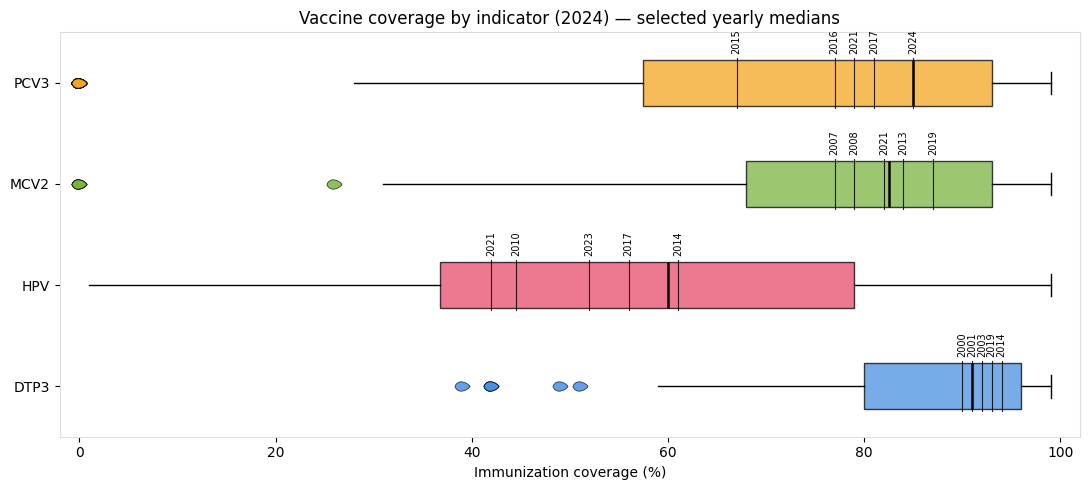

In [53]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
import pandas as pd
import numpy as np
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']

# --- 2024 country-level data for the boxplot ---
TARGET_YEAR = 2024
recent = vaccine_all_years[
    (vaccine_all_years['TimeDim'] == TARGET_YEAR) &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
].copy()
recent['NumericValue'] = pd.to_numeric(recent['NumericValue'], errors='coerce')
recent = recent.dropna(subset=['NumericValue'])
print(f"Country records available for {TARGET_YEAR}:")
print(recent['Vaccine'].value_counts())

groups = [recent[recent['Vaccine'] == v]['NumericValue'].values for v in order]

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

# Boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
# Bold black current-year median line
for m in bp['medians']:
    m.set_color('black'); m.set_linewidth(1.8)
# Hide left-whisker caps
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)
# Outlier teardrops
for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP)
    flier.set_markersize(12)
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5)
    flier.set_alpha(0.85)
    flier.set_linestyle('none')
# zorder
for w in bp['whiskers']: w.set_zorder(3)
for c in bp['caps']:     c.set_zorder(3)
for b in bp['boxes']:    b.set_zorder(3)
for m in bp['medians']:  m.set_zorder(5)
for f in bp['fliers']:   f.set_zorder(4)

# --- 4-6 yearly medians per indicator, inside the box, well-spaced ---
BOX_HALF = 0.25
N_KEEP   = 5     # target count per indicator (4-6 ok)

for i, vaccine in enumerate(order):
    y_pos = i + 1
    vm = medians[medians['Vaccine'] == vaccine].sort_values('Year').reset_index(drop=True)
    if vm.empty or len(groups[i]) == 0:
        continue

    # Drop medians that fall outside the current-year IQR (the "box")
    q1, q3 = np.percentile(groups[i], [25, 75])
    vm_in = vm[(vm['Median'] >= q1) & (vm['Median'] <= q3)]
    if vm_in.empty:
        continue

    # Pick N_KEEP medians spread maximally across the value range
    if len(vm_in) > N_KEEP:
        srt = vm_in.sort_values('Median').reset_index(drop=True)
        targets = np.linspace(srt['Median'].min(), srt['Median'].max(), N_KEEP)
        chosen = []
        for t in targets:
            avail = srt[~srt.index.isin(chosen)]
            chosen.append((avail['Median'] - t).abs().idxmin())
        selected = srt.loc[chosen].sort_values('Year').reset_index(drop=True)
    else:
        selected = vm_in.sort_values('Year').reset_index(drop=True)

    # Black lines inside the box + year labels above
    for year, val in zip(selected['Year'].values, selected['Median'].values):
        ax.plot([val, val], [y_pos - BOX_HALF, y_pos + BOX_HALF],
                color='black', linewidth=0.8, alpha=0.85, zorder=3.5)
        ax.annotate(str(year), (val, y_pos + BOX_HALF + 0.04),
                    ha='center', va='bottom', fontsize=7,
                    rotation=90, color='black')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_title(f'Vaccine coverage by indicator ({TARGET_YEAR}) — selected yearly medians')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_boxplot_yearly_medians.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\4042336644.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


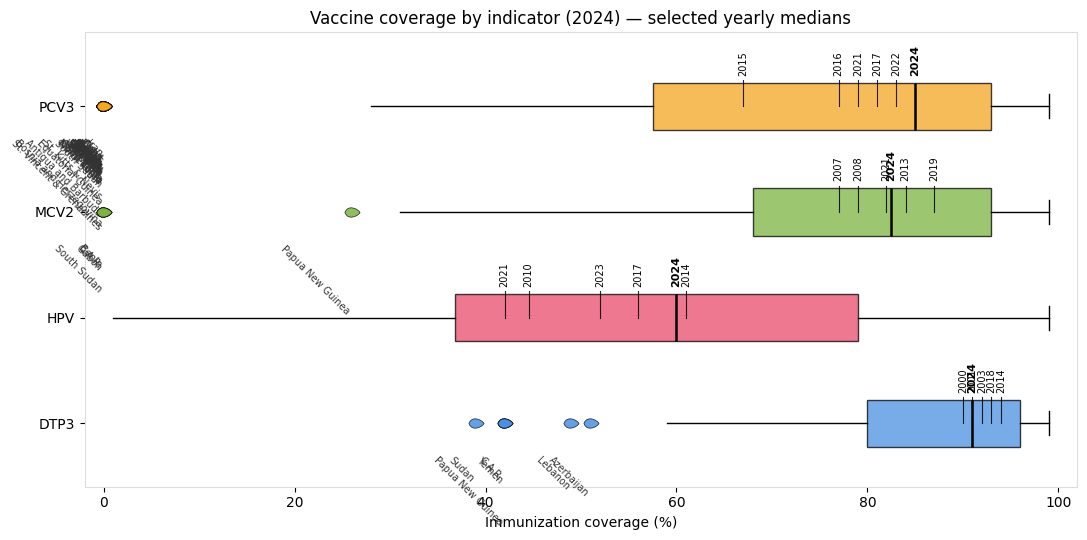

In [54]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
import pandas as pd
import numpy as np
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
TARGET_YEAR = 2024
N_KEEP = 5
BOX_HALF = 0.25

# Country code → short name mapping (built from your earlier vaccine_df)
code_to_name = (vaccine_df.drop_duplicates(subset='LocationCode')
                          .set_index('LocationCode')['LocationShort']
                          .to_dict())

# 2024 country-level data
recent = vaccine_all_years[
    (vaccine_all_years['TimeDim'] == TARGET_YEAR) &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
].copy()
recent['NumericValue'] = pd.to_numeric(recent['NumericValue'], errors='coerce')
recent = recent.dropna(subset=['NumericValue'])
groups = [recent[recent['Vaccine'] == v]['NumericValue'].values for v in order]

fig, ax = plt.subplots(figsize=(11, 5.5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for m in bp['medians']:
    m.set_color('black'); m.set_linewidth(1.8)
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0: cap.set_visible(False)
for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP); flier.set_markersize(12)
    flier.set_markerfacecolor(color); flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5); flier.set_alpha(0.85)
    flier.set_linestyle('none')
for w in bp['whiskers']: w.set_zorder(3)
for c in bp['caps']:     c.set_zorder(3)
for b in bp['boxes']:    b.set_zorder(3)
for m in bp['medians']:  m.set_zorder(5)
for f in bp['fliers']:   f.set_zorder(4)

# --- Per-vaccine annotations ---
for i, vaccine in enumerate(order):
    y_pos = i + 1
    vacc_data = recent[recent['Vaccine'] == vaccine]
    if vacc_data.empty:
        continue
    vals_2024 = vacc_data['NumericValue'].values
    q1, q3 = np.percentile(vals_2024, [25, 75])
    iqr = q3 - q1
    lo_fence = q1 - 1.5 * iqr
    hi_fence = q3 + 1.5 * iqr

    # 1) Annotate the bold (2024) median
    cur_med = np.median(vals_2024)
    ax.annotate(str(TARGET_YEAR), (cur_med, y_pos + BOX_HALF + 0.04),
                ha='center', va='bottom', fontsize=8, fontweight='bold',
                rotation=90, color='black')

    # 2) Historical year medians — inside box, half height, all black, exclude 2024
    vm = (medians[(medians['Vaccine'] == vaccine) &
                  (medians['Year'] != TARGET_YEAR)]
          .sort_values('Year').reset_index(drop=True))
    vm_in = vm[(vm['Median'] >= q1) & (vm['Median'] <= q3)]
    if not vm_in.empty:
        if len(vm_in) > N_KEEP:
            srt = vm_in.sort_values('Median').reset_index(drop=True)
            targets = np.linspace(srt['Median'].min(), srt['Median'].max(), N_KEEP)
            chosen = []
            for t in targets:
                avail = srt[~srt.index.isin(chosen)]
                chosen.append((avail['Median'] - t).abs().idxmin())
            selected = srt.loc[chosen]
        else:
            selected = vm_in
        for year, val in zip(selected['Year'].values, selected['Median'].values):
            # Only the upper half of the box
            ax.plot([val, val], [y_pos, y_pos + BOX_HALF],
                    color='black', linewidth=0.8, alpha=0.85, zorder=3.5)
            ax.annotate(str(year), (val, y_pos + BOX_HALF + 0.04),
                        ha='center', va='bottom', fontsize=7,
                        rotation=90, color='black')

    # 3) Label outlier drops with country name at -45°
    outliers = vacc_data[(vacc_data['NumericValue'] < lo_fence) |
                         (vacc_data['NumericValue'] > hi_fence)]
    for _, row in outliers.iterrows():
        name = code_to_name.get(row['SpatialDim'], row['SpatialDim'])
        ax.text(row['NumericValue'], y_pos - 0.30, name,
                rotation=-45, ha='right', va='top',
                fontsize=7, color='#333')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_ylim(0.4, 4.7)
ax.set_title(f'Vaccine coverage by indicator ({TARGET_YEAR}) — selected yearly medians')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_boxplot_yearly_medians.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\4109820230.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


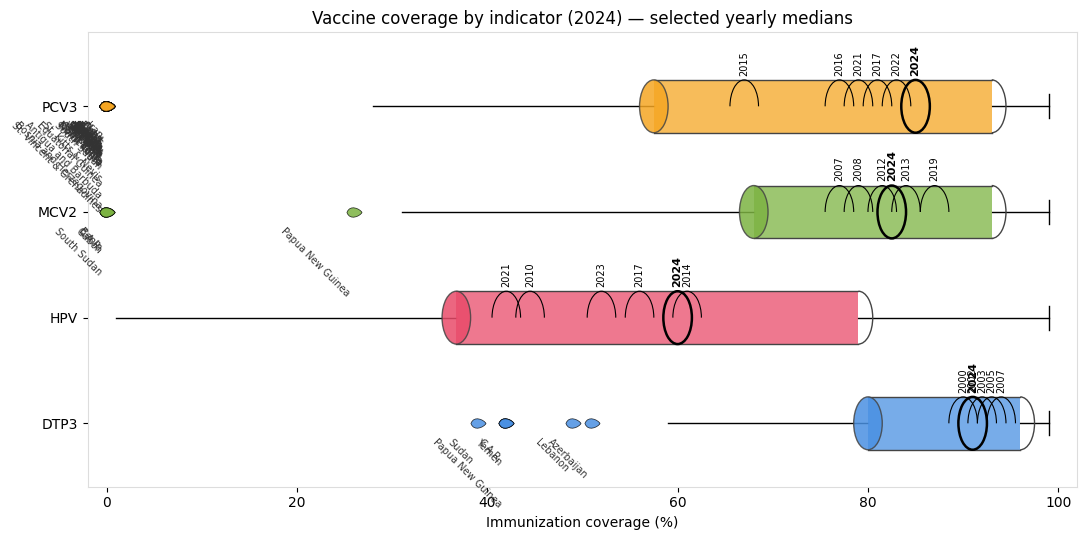

In [55]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Ellipse, Arc, Rectangle
import pandas as pd
import numpy as np
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
TARGET_YEAR = 2024
N_KEEP = 5
BOX_H = 0.5
ELLIPSE_W = 1.5                                  # horizontal half-axis of cylinder ends
EXCLUDE_MEDIANS = {('DTP3', 2001), ('MCV2', 2021)}

code_to_name = (vaccine_df.drop_duplicates(subset='LocationCode')
                          .set_index('LocationCode')['LocationShort']
                          .to_dict())

recent = vaccine_all_years[
    (vaccine_all_years['TimeDim'] == TARGET_YEAR) &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
].copy()
recent['NumericValue'] = pd.to_numeric(recent['NumericValue'], errors='coerce')
recent = recent.dropna(subset=['NumericValue'])
groups = [recent[recent['Vaccine'] == v]['NumericValue'].values for v in order]

fig, ax = plt.subplots(figsize=(11, 5.5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

# Hide the default rectangle box and the default median line — we redraw them
for box in bp['boxes']:    box.set_visible(False)
for med in bp['medians']:  med.set_visible(False)

# Hide left-whisker caps
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

# Outlier drops (teardrop marker)
for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP); flier.set_markersize(12)
    flier.set_markerfacecolor(color); flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5); flier.set_alpha(0.85)
    flier.set_linestyle('none')

for w in bp['whiskers']: w.set_zorder(2)
for c in bp['caps']:     c.set_zorder(2)
for f in bp['fliers']:   f.set_zorder(5)

# --- Per-vaccine cylindrical boxes ---
for i, vaccine in enumerate(order):
    y_pos = i + 1
    vacc_data = recent[recent['Vaccine'] == vaccine]
    if vacc_data.empty:
        continue
    vals_2024 = vacc_data['NumericValue'].values
    q1, q3 = np.percentile(vals_2024, [25, 75])
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    median_2024 = np.median(vals_2024)
    color = colors[i]

    # Cylinder body
    ax.add_patch(Rectangle((q1, y_pos - BOX_H/2), q3 - q1, BOX_H,
                           facecolor=color, alpha=0.75, linewidth=0, zorder=2.5))
    ax.plot([q1, q3], [y_pos + BOX_H/2]*2, color='#444', lw=1, zorder=2.6)
    ax.plot([q1, q3], [y_pos - BOX_H/2]*2, color='#444', lw=1, zorder=2.6)
    # Left ellipse (front face)
    ax.add_patch(Ellipse((q1, y_pos), 2*ELLIPSE_W, BOX_H,
                         facecolor=color, alpha=0.85,
                         edgecolor='#444', lw=1, zorder=2.7))
    # Right back-rim (only the curve visible)
    ax.add_patch(Arc((q3, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=-90, theta2=90, color='#444', lw=1, zorder=2.6))

    # 2024 median: full ellipse "rib"
    ax.add_patch(Ellipse((median_2024, y_pos), 2*ELLIPSE_W, BOX_H,
                         facecolor='none', edgecolor='black',
                         lw=1.8, zorder=3.5))
    ax.annotate(str(TARGET_YEAR),
                (median_2024, y_pos + BOX_H/2 + 0.04),
                ha='center', va='bottom', fontsize=8, fontweight='bold',
                rotation=90, color='black')

    # Historical medians (with exclusions and 2024 removed)
    vm = (medians[(medians['Vaccine'] == vaccine) &
                  (medians['Year'] != TARGET_YEAR)]
          .sort_values('Year').reset_index(drop=True))
    excl = {y for v, y in EXCLUDE_MEDIANS if v == vaccine}
    vm = vm[~vm['Year'].isin(excl)]
    vm_in = vm[(vm['Median'] >= q1) & (vm['Median'] <= q3)]
    if not vm_in.empty:
        if len(vm_in) > N_KEEP:
            srt = vm_in.sort_values('Median').reset_index(drop=True)
            targets = np.linspace(srt['Median'].min(), srt['Median'].max(), N_KEEP)
            chosen = []
            for t in targets:
                avail = srt[~srt.index.isin(chosen)]
                chosen.append((avail['Median'] - t).abs().idxmin())
            selected = srt.loc[chosen]
        else:
            selected = vm_in
        for year, val in zip(selected['Year'].values, selected['Median'].values):
            # Top half of the rib (halfway through the cylinder)
            ax.add_patch(Arc((val, y_pos), 2*ELLIPSE_W, BOX_H,
                             theta1=0, theta2=180,
                             color='black', lw=0.8, zorder=3.4))
            ax.annotate(str(year), (val, y_pos + BOX_H/2 + 0.04),
                        ha='center', va='bottom', fontsize=7,
                        rotation=90, color='black')

    # Outlier labels — position via offset_points so they actually sit at the drop
    outliers = vacc_data[(vacc_data['NumericValue'] < lo_fence) |
                         (vacc_data['NumericValue'] > hi_fence)]
    for _, row in outliers.iterrows():
        name = code_to_name.get(row['SpatialDim'], row['SpatialDim'])
        ax.annotate(name, xy=(row['NumericValue'], y_pos),
                    xytext=(-2, -10), textcoords='offset points',
                    rotation=-45, ha='right', va='top',
                    fontsize=7, color='#333')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_ylim(0.4, 4.7)
ax.set_title(f'Vaccine coverage by indicator ({TARGET_YEAR}) — selected yearly medians')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_cylinder_syringes.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\2687285677.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


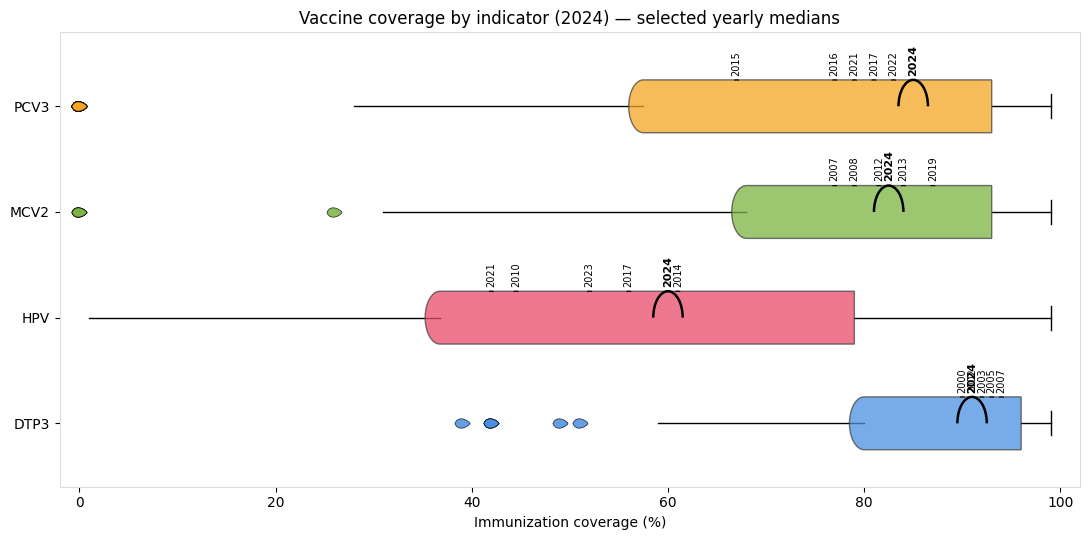

In [56]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Arc, Polygon
import pandas as pd
import numpy as np
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
TARGET_YEAR = 2024
N_KEEP = 5
BOX_H = 0.5
ELLIPSE_W = 1.5
EXCLUDE_MEDIANS = {('DTP3', 2001), ('MCV2', 2021)}

recent = vaccine_all_years[
    (vaccine_all_years['TimeDim'] == TARGET_YEAR) &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
].copy()
recent['NumericValue'] = pd.to_numeric(recent['NumericValue'], errors='coerce')
recent = recent.dropna(subset=['NumericValue'])
groups = [recent[recent['Vaccine'] == v]['NumericValue'].values for v in order]

fig, ax = plt.subplots(figsize=(11, 5.5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

for box in bp['boxes']:    box.set_visible(False)
for med in bp['medians']:  med.set_visible(False)
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

# Outlier teardrops (still drawn, just NOT labelled with country names)
for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP)
    flier.set_markersize(12)
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5)
    flier.set_alpha(0.85)
    flier.set_linestyle('none')

for w in bp['whiskers']: w.set_zorder(2)
for c in bp['caps']:     c.set_zorder(2)
for f in bp['fliers']:   f.set_zorder(5)

def left_half_ellipse(cx, cy, rx, ry, n=40):
    """Points along the left half of an ellipse, top → left → bottom."""
    t = np.linspace(np.pi/2, 3*np.pi/2, n)
    return list(zip(cx + rx*np.cos(t), cy + ry*np.sin(t)))

for i, vaccine in enumerate(order):
    y_pos = i + 1
    vacc_data = recent[recent['Vaccine'] == vaccine]
    if vacc_data.empty:
        continue
    vals_2024 = vacc_data['NumericValue'].values
    q1, q3 = np.percentile(vals_2024, [25, 75])
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    median_2024 = np.median(vals_2024)
    color = colors[i]

    # Single closed polygon: left half-ellipse + bottom + right vertical edge + top.
    # One fill, one alpha → no two-tone overlap.
    pts = left_half_ellipse(q1, y_pos, ELLIPSE_W, BOX_H/2)
    pts.append((q3, y_pos - BOX_H/2))
    pts.append((q3, y_pos + BOX_H/2))
    ax.add_patch(Polygon(pts, closed=True,
                         facecolor=color, alpha=0.75,
                         edgecolor='#444', lw=1, zorder=2.5))

    # 2024 median: HALF circle (top semicircle) — only the visible front of the rib
    ax.add_patch(Arc((median_2024, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=0, theta2=180,
                     color='black', lw=1.8, zorder=3.5))
    ax.annotate(str(TARGET_YEAR),
                (median_2024, y_pos + BOX_H/2 + 0.04),
                ha='center', va='bottom', fontsize=8, fontweight='bold',
                rotation=90, color='black')

    # Historical medians (with exclusions)
    vm = (medians[(medians['Vaccine'] == vaccine) &
                  (medians['Year'] != TARGET_YEAR)]
          .sort_values('Year').reset_index(drop=True))
    excl = {y for v, y in EXCLUDE_MEDIANS if v == vaccine}
    vm = vm[~vm['Year'].isin(excl)]
    vm_in = vm[(vm['Median'] >= q1) & (vm['Median'] <= q3)]
    if not vm_in.empty:
        if len(vm_in) > N_KEEP:
            srt = vm_in.sort_values('Median').reset_index(drop=True)
            targets = np.linspace(srt['Median'].min(), srt['Median'].max(), N_KEEP)
            chosen = []
            for t in targets:
                avail = srt[~srt.index.isin(chosen)]
                chosen.append((avail['Median'] - t).abs().idxmin())
            selected = srt.loc[chosen]
        else:
            selected = vm_in
        for year, val in zip(selected['Year'].values, selected['Median'].values):
            # Historical median: QUARTER circle, top-centred
            ax.add_patch(Arc((val, y_pos), 2*ELLIPSE_W, BOX_H,
                             theta1=45, theta2=135,
                             color='black', lw=0.8, zorder=3.4))
            ax.annotate(str(year), (val, y_pos + BOX_H/2 + 0.04),
                        ha='center', va='bottom', fontsize=7,
                        rotation=90, color='black')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_ylim(0.4, 4.7)
ax.set_title(f'Vaccine coverage by indicator ({TARGET_YEAR}) — selected yearly medians')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_cylinder_syringes.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\570203873.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


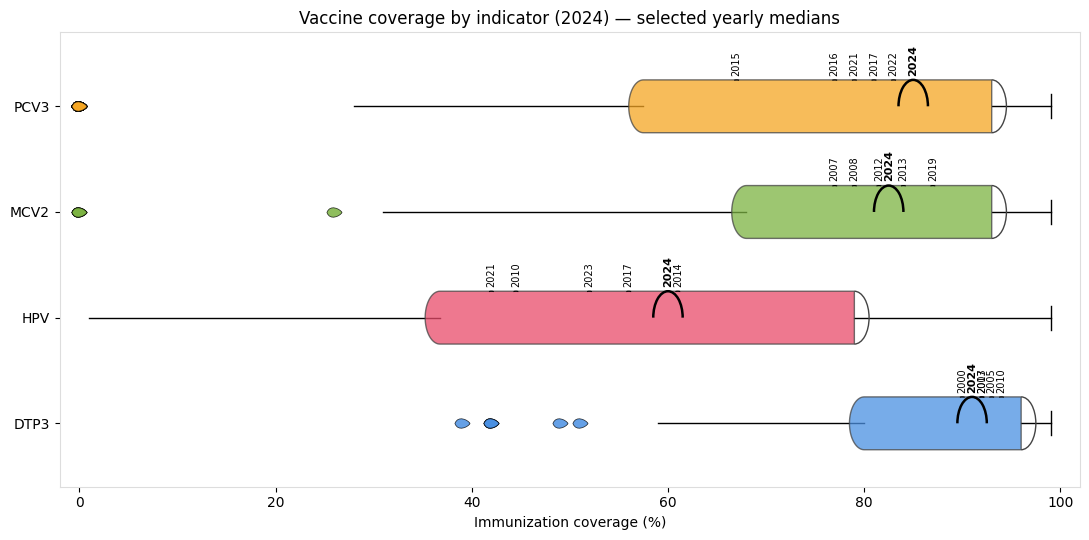

In [57]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Arc, Polygon
import pandas as pd
import numpy as np
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
TARGET_YEAR = 2024
N_KEEP = 5
BOX_H = 0.5
ELLIPSE_W = 1.5
EXCLUDE_MEDIANS = {('DTP3', 2001), ('MCV2', 2021)}
MIN_DIST_FROM_CURRENT = 1.0   # drop historical years within 1 pp of the 2024 median

recent = vaccine_all_years[
    (vaccine_all_years['TimeDim'] == TARGET_YEAR) &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
].copy()
recent['NumericValue'] = pd.to_numeric(recent['NumericValue'], errors='coerce')
recent = recent.dropna(subset=['NumericValue'])
groups = [recent[recent['Vaccine'] == v]['NumericValue'].values for v in order]

fig, ax = plt.subplots(figsize=(11, 5.5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

for box in bp['boxes']:    box.set_visible(False)
for med in bp['medians']:  med.set_visible(False)
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP); flier.set_markersize(12)
    flier.set_markerfacecolor(color); flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5); flier.set_alpha(0.85)
    flier.set_linestyle('none')

for w in bp['whiskers']: w.set_zorder(2)
for c in bp['caps']:     c.set_zorder(2)
for f in bp['fliers']:   f.set_zorder(5)

def left_half_ellipse(cx, cy, rx, ry, n=40):
    t = np.linspace(np.pi/2, 3*np.pi/2, n)
    return list(zip(cx + rx*np.cos(t), cy + ry*np.sin(t)))

for i, vaccine in enumerate(order):
    y_pos = i + 1
    vacc_data = recent[recent['Vaccine'] == vaccine]
    if vacc_data.empty:
        continue
    vals_2024 = vacc_data['NumericValue'].values
    q1, q3 = np.percentile(vals_2024, [25, 75])
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    median_2024 = np.median(vals_2024)
    color = colors[i]

    # Cylinder body: front cap (left half-ellipse OUTWARD) + body rectangle
    pts = left_half_ellipse(q1, y_pos, ELLIPSE_W, BOX_H/2)
    pts.append((q3, y_pos - BOX_H/2))
    pts.append((q3, y_pos + BOX_H/2))
    ax.add_patch(Polygon(pts, closed=True,
                         facecolor=color, alpha=0.75,
                         edgecolor='#444', lw=1, zorder=2.5))

    # Back rim: right half of ellipse at q3, outline only (sticks out past q3)
    ax.add_patch(Arc((q3, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=-90, theta2=90,
                     color='#444', lw=1, zorder=2.7))

    # 2024 median: top HALF arc
    ax.add_patch(Arc((median_2024, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=0, theta2=180,
                     color='black', lw=1.8, zorder=3.5))
    ax.annotate(str(TARGET_YEAR),
                (median_2024, y_pos + BOX_H/2 + 0.04),
                ha='center', va='bottom', fontsize=8, fontweight='bold',
                rotation=90, color='black')

    # Historical medians (with exclusions + auto-distance filter from 2024)
    vm = (medians[(medians['Vaccine'] == vaccine) &
                  (medians['Year'] != TARGET_YEAR)]
          .sort_values('Year').reset_index(drop=True))
    excl = {y for v, y in EXCLUDE_MEDIANS if v == vaccine}
    vm = vm[~vm['Year'].isin(excl)]
    vm_in = vm[(vm['Median'] >= q1) & (vm['Median'] <= q3)]
    vm_in = vm_in[abs(vm_in['Median'] - median_2024) >= MIN_DIST_FROM_CURRENT]

    if not vm_in.empty:
        if len(vm_in) > N_KEEP:
            srt = vm_in.sort_values('Median').reset_index(drop=True)
            targets = np.linspace(srt['Median'].min(), srt['Median'].max(), N_KEEP)
            chosen = []
            for t in targets:
                avail = srt[~srt.index.isin(chosen)]
                chosen.append((avail['Median'] - t).abs().idxmin())
            selected = srt.loc[chosen]
        else:
            selected = vm_in
        for year, val in zip(selected['Year'].values, selected['Median'].values):
            ax.add_patch(Arc((val, y_pos), 2*ELLIPSE_W, BOX_H,
                             theta1=45, theta2=135,
                             color='black', lw=0.8, zorder=3.4))
            ax.annotate(str(year), (val, y_pos + BOX_H/2 + 0.04),
                        ha='center', va='bottom', fontsize=7,
                        rotation=90, color='black')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_ylim(0.4, 4.7)
ax.set_title(f'Vaccine coverage by indicator ({TARGET_YEAR}) — selected yearly medians')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_cylinder_syringes.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\1181929898.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


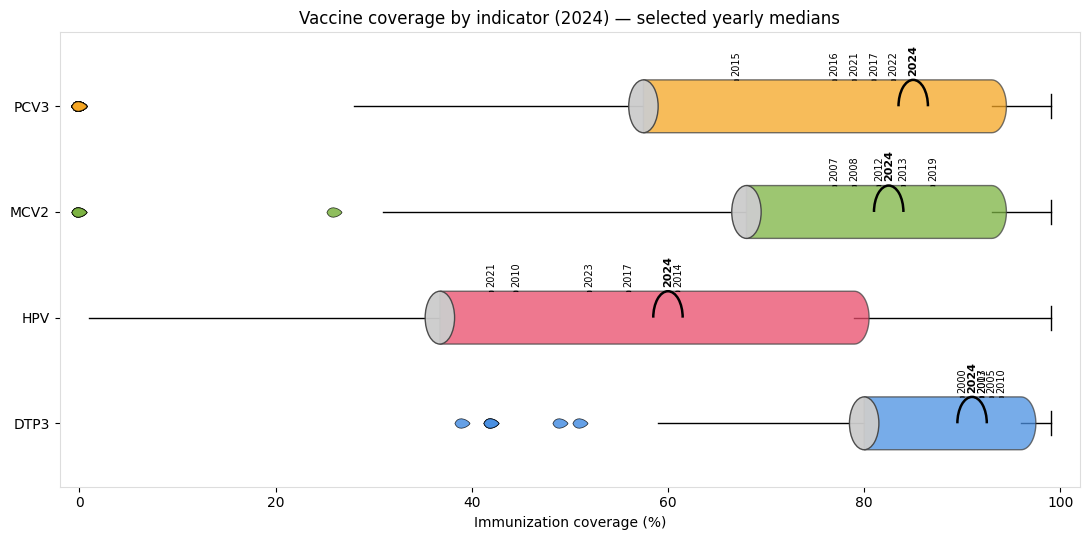

In [58]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Arc, Polygon, Ellipse
import pandas as pd
import numpy as np
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
TARGET_YEAR = 2024
N_KEEP = 5
BOX_H = 0.5
ELLIPSE_W = 1.5
EXCLUDE_MEDIANS = {('DTP3', 2001), ('MCV2', 2021)}
MIN_DIST_FROM_CURRENT = 1.0
FRONT_GRAY = '#cccccc'

recent = vaccine_all_years[
    (vaccine_all_years['TimeDim'] == TARGET_YEAR) &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
].copy()
recent['NumericValue'] = pd.to_numeric(recent['NumericValue'], errors='coerce')
recent = recent.dropna(subset=['NumericValue'])
groups = [recent[recent['Vaccine'] == v]['NumericValue'].values for v in order]

fig, ax = plt.subplots(figsize=(11, 5.5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

for box in bp['boxes']:    box.set_visible(False)
for med in bp['medians']:  med.set_visible(False)
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP); flier.set_markersize(12)
    flier.set_markerfacecolor(color); flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5); flier.set_alpha(0.85)
    flier.set_linestyle('none')

for w in bp['whiskers']: w.set_zorder(2)
for c in bp['caps']:     c.set_zorder(2)
for f in bp['fliers']:   f.set_zorder(5)

for i, vaccine in enumerate(order):
    y_pos = i + 1
    vacc_data = recent[recent['Vaccine'] == vaccine]
    if vacc_data.empty:
        continue
    vals_2024 = vacc_data['NumericValue'].values
    q1, q3 = np.percentile(vals_2024, [25, 75])
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    median_2024 = np.median(vals_2024)
    color = colors[i]

    # Body + filled back cap as ONE polygon (no vertical seam line on the right)
    body_pts = [(q1, y_pos - BOX_H/2), (q3, y_pos - BOX_H/2)]
    t = np.linspace(-np.pi/2, np.pi/2, 30)        # outward right cap, bottom→right→top
    body_pts.extend([(q3 + ELLIPSE_W*np.cos(a),
                      y_pos + (BOX_H/2)*np.sin(a)) for a in t])
    body_pts.append((q1, y_pos + BOX_H/2))
    ax.add_patch(Polygon(body_pts, closed=True,
                         facecolor=color, alpha=0.75,
                         edgecolor='#444', lw=1, zorder=2.5))

    # Front face: FULL GRAY ellipse on top of the body's left edge
    ax.add_patch(Ellipse((q1, y_pos), 2*ELLIPSE_W, BOX_H,
                         facecolor=FRONT_GRAY, alpha=0.95,
                         edgecolor='#444', lw=1, zorder=2.7))

    # 2024 median — top half-ellipse
    ax.add_patch(Arc((median_2024, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=0, theta2=180,
                     color='black', lw=1.8, zorder=3.5))
    ax.annotate(str(TARGET_YEAR),
                (median_2024, y_pos + BOX_H/2 + 0.04),
                ha='center', va='bottom', fontsize=8, fontweight='bold',
                rotation=90, color='black')

    # Historical year medians — top quarter arcs
    vm = (medians[(medians['Vaccine'] == vaccine) &
                  (medians['Year'] != TARGET_YEAR)]
          .sort_values('Year').reset_index(drop=True))
    excl = {y for v, y in EXCLUDE_MEDIANS if v == vaccine}
    vm = vm[~vm['Year'].isin(excl)]
    vm_in = vm[(vm['Median'] >= q1) & (vm['Median'] <= q3)]
    vm_in = vm_in[abs(vm_in['Median'] - median_2024) >= MIN_DIST_FROM_CURRENT]

    if not vm_in.empty:
        if len(vm_in) > N_KEEP:
            srt = vm_in.sort_values('Median').reset_index(drop=True)
            targets = np.linspace(srt['Median'].min(), srt['Median'].max(), N_KEEP)
            chosen = []
            for t in targets:
                avail = srt[~srt.index.isin(chosen)]
                chosen.append((avail['Median'] - t).abs().idxmin())
            selected = srt.loc[chosen]
        else:
            selected = vm_in
        for year, val in zip(selected['Year'].values, selected['Median'].values):
            ax.add_patch(Arc((val, y_pos), 2*ELLIPSE_W, BOX_H,
                             theta1=45, theta2=135,
                             color='black', lw=0.8, zorder=3.4))
            ax.annotate(str(year), (val, y_pos + BOX_H/2 + 0.04),
                        ha='center', va='bottom', fontsize=7,
                        rotation=90, color='black')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_ylim(0.4, 4.7)
ax.set_title(f'Vaccine coverage by indicator ({TARGET_YEAR}) — selected yearly medians')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_cylinder_syringes.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\833768570.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


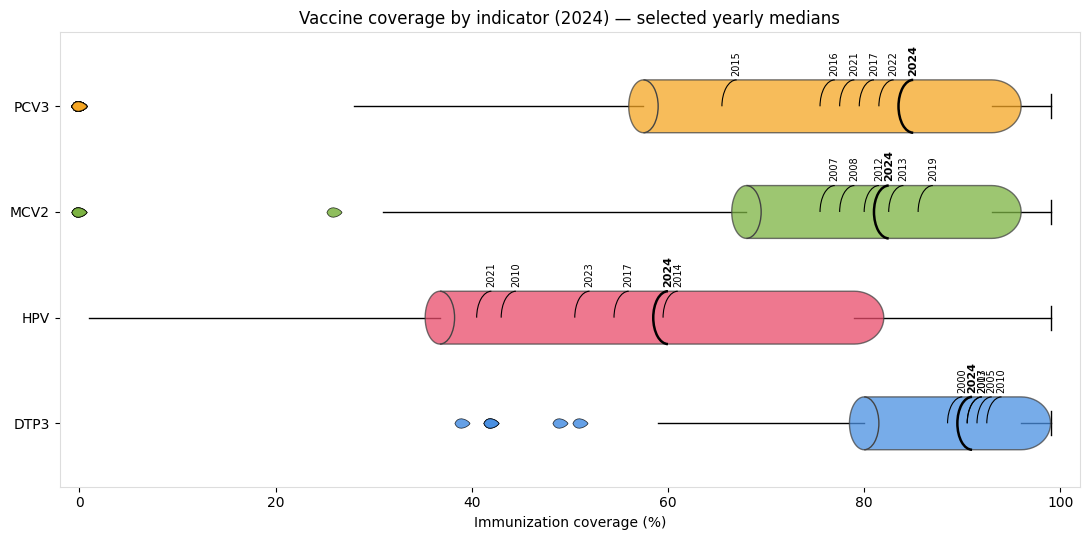

In [59]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Arc, Polygon, Ellipse
import pandas as pd
import numpy as np
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
TARGET_YEAR = 2024
N_KEEP = 5
BOX_H = 0.5
ELLIPSE_W = 1.5         # front cap horizontal half-axis
BACK_CAP_W = 3.0        # back cap horizontal half-axis (wider → overlaps whisker)
EXCLUDE_MEDIANS = {('DTP3', 2001), ('MCV2', 2021)}
MIN_DIST_FROM_CURRENT = 1.0

recent = vaccine_all_years[
    (vaccine_all_years['TimeDim'] == TARGET_YEAR) &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
].copy()
recent['NumericValue'] = pd.to_numeric(recent['NumericValue'], errors='coerce')
recent = recent.dropna(subset=['NumericValue'])
groups = [recent[recent['Vaccine'] == v]['NumericValue'].values for v in order]

fig, ax = plt.subplots(figsize=(11, 5.5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

for box in bp['boxes']:    box.set_visible(False)
for med in bp['medians']:  med.set_visible(False)
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP); flier.set_markersize(12)
    flier.set_markerfacecolor(color); flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5); flier.set_alpha(0.85)
    flier.set_linestyle('none')

# Whiskers behind the body so they get hidden inside the caps
for w in bp['whiskers']: w.set_zorder(2)
for c in bp['caps']:     c.set_zorder(2)
for f in bp['fliers']:   f.set_zorder(5)

for i, vaccine in enumerate(order):
    y_pos = i + 1
    vacc_data = recent[recent['Vaccine'] == vaccine]
    if vacc_data.empty:
        continue
    vals_2024 = vacc_data['NumericValue'].values
    q1, q3 = np.percentile(vals_2024, [25, 75])
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    median_2024 = np.median(vals_2024)
    color = colors[i]

    # Single capsule polygon: front cap + body + (wider) back cap, all one fill
    body_pts = []
    # Front cap (left half-ellipse OUTWARD)
    t1 = np.linspace(np.pi/2, 3*np.pi/2, 30)
    body_pts.extend([(q1 + ELLIPSE_W*np.cos(a),
                      y_pos + (BOX_H/2)*np.sin(a)) for a in t1])
    body_pts.append((q3, y_pos - BOX_H/2))
    # Back cap (right half-ellipse OUTWARD, extended)
    t2 = np.linspace(-np.pi/2, np.pi/2, 30)
    body_pts.extend([(q3 + BACK_CAP_W*np.cos(a),
                      y_pos + (BOX_H/2)*np.sin(a)) for a in t2])
    ax.add_patch(Polygon(body_pts, closed=True,
                         facecolor=color, alpha=0.75,
                         edgecolor='#444', lw=1, zorder=2.5))

    # Front face boundary — right-half ellipse outline at q1 (inside the body)
    ax.add_patch(Arc((q1, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=-90, theta2=90, color='#444', lw=1, zorder=2.7))

    # 2024 median: LEFT-half ellipse arc (touches top AND bottom of cylinder)
    ax.add_patch(Arc((median_2024, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=90, theta2=270,
                     color='black', lw=1.8, zorder=3.5))
    ax.annotate(str(TARGET_YEAR),
                (median_2024, y_pos + BOX_H/2 + 0.04),
                ha='center', va='bottom', fontsize=8, fontweight='bold',
                rotation=90, color='black')

    # Historical medians: top-LEFT quarter arc (1/4 of an ellipse, top→left)
    vm = (medians[(medians['Vaccine'] == vaccine) &
                  (medians['Year'] != TARGET_YEAR)]
          .sort_values('Year').reset_index(drop=True))
    excl = {y for v, y in EXCLUDE_MEDIANS if v == vaccine}
    vm = vm[~vm['Year'].isin(excl)]
    vm_in = vm[(vm['Median'] >= q1) & (vm['Median'] <= q3)]
    vm_in = vm_in[abs(vm_in['Median'] - median_2024) >= MIN_DIST_FROM_CURRENT]

    if not vm_in.empty:
        if len(vm_in) > N_KEEP:
            srt = vm_in.sort_values('Median').reset_index(drop=True)
            targets = np.linspace(srt['Median'].min(), srt['Median'].max(), N_KEEP)
            chosen = []
            for t in targets:
                avail = srt[~srt.index.isin(chosen)]
                chosen.append((avail['Median'] - t).abs().idxmin())
            selected = srt.loc[chosen]
        else:
            selected = vm_in
        for year, val in zip(selected['Year'].values, selected['Median'].values):
            ax.add_patch(Arc((val, y_pos), 2*ELLIPSE_W, BOX_H,
                             theta1=90, theta2=180,
                             color='black', lw=0.8, zorder=3.4))
            ax.annotate(str(year), (val, y_pos + BOX_H/2 + 0.04),
                        ha='center', va='bottom', fontsize=7,
                        rotation=90, color='black')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_ylim(0.4, 4.7)
ax.set_title(f'Vaccine coverage by indicator ({TARGET_YEAR}) — selected yearly medians')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_cylinder_syringes.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\3097185908.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


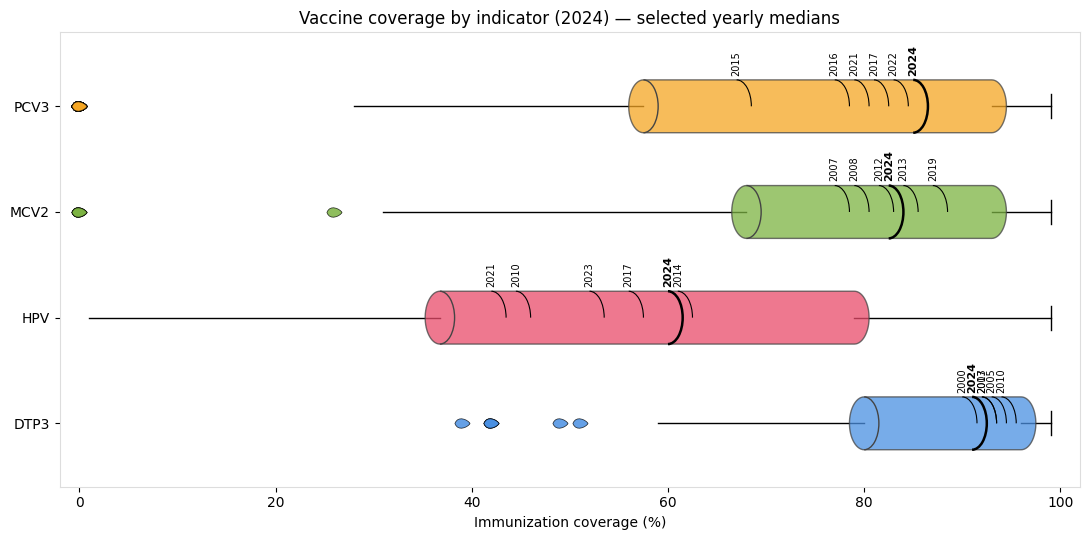

In [60]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Arc, Polygon, Ellipse
import pandas as pd
import numpy as np
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
TARGET_YEAR = 2024
N_KEEP = 5
BOX_H = 0.5
ELLIPSE_W = 1.5
BACK_CAP_W = 1.5            # reverted to match the front
EXCLUDE_MEDIANS = {('DTP3', 2001), ('MCV2', 2021)}
MIN_DIST_FROM_CURRENT = 1.0

recent = vaccine_all_years[
    (vaccine_all_years['TimeDim'] == TARGET_YEAR) &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
].copy()
recent['NumericValue'] = pd.to_numeric(recent['NumericValue'], errors='coerce')
recent = recent.dropna(subset=['NumericValue'])
groups = [recent[recent['Vaccine'] == v]['NumericValue'].values for v in order]

fig, ax = plt.subplots(figsize=(11, 5.5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

for box in bp['boxes']:    box.set_visible(False)
for med in bp['medians']:  med.set_visible(False)
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP); flier.set_markersize(12)
    flier.set_markerfacecolor(color); flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5); flier.set_alpha(0.85)
    flier.set_linestyle('none')

for w in bp['whiskers']: w.set_zorder(2)
for c in bp['caps']:     c.set_zorder(2)
for f in bp['fliers']:   f.set_zorder(5)

for i, vaccine in enumerate(order):
    y_pos = i + 1
    vacc_data = recent[recent['Vaccine'] == vaccine]
    if vacc_data.empty:
        continue
    vals_2024 = vacc_data['NumericValue'].values
    q1, q3 = np.percentile(vals_2024, [25, 75])
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    median_2024 = np.median(vals_2024)
    color = colors[i]

    # Cylinder = single capsule polygon (front cap + body + back cap)
    body_pts = []
    t1 = np.linspace(np.pi/2, 3*np.pi/2, 30)
    body_pts.extend([(q1 + ELLIPSE_W*np.cos(a),
                      y_pos + (BOX_H/2)*np.sin(a)) for a in t1])
    body_pts.append((q3, y_pos - BOX_H/2))
    t2 = np.linspace(-np.pi/2, np.pi/2, 30)
    body_pts.extend([(q3 + BACK_CAP_W*np.cos(a),
                      y_pos + (BOX_H/2)*np.sin(a)) for a in t2])
    ax.add_patch(Polygon(body_pts, closed=True,
                         facecolor=color, alpha=0.75,
                         edgecolor='#444', lw=1, zorder=2.5))

    # Front face boundary (right-half ellipse outline at q1)
    ax.add_patch(Arc((q1, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=-90, theta2=90, color='#444', lw=1, zorder=2.7))

    # 2024 median: RIGHT-half ellipse arc (mirrored — touches top AND bottom on the right)
    ax.add_patch(Arc((median_2024, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=-90, theta2=90,
                     color='black', lw=1.8, zorder=3.5))
    ax.annotate(str(TARGET_YEAR),
                (median_2024, y_pos + BOX_H/2 + 0.04),
                ha='center', va='bottom', fontsize=8, fontweight='bold',
                rotation=90, color='black')

    # Historical medians: TOP-RIGHT quarter (mirrored — top → right)
    vm = (medians[(medians['Vaccine'] == vaccine) &
                  (medians['Year'] != TARGET_YEAR)]
          .sort_values('Year').reset_index(drop=True))
    excl = {y for v, y in EXCLUDE_MEDIANS if v == vaccine}
    vm = vm[~vm['Year'].isin(excl)]
    vm_in = vm[(vm['Median'] >= q1) & (vm['Median'] <= q3)]
    vm_in = vm_in[abs(vm_in['Median'] - median_2024) >= MIN_DIST_FROM_CURRENT]

    if not vm_in.empty:
        if len(vm_in) > N_KEEP:
            srt = vm_in.sort_values('Median').reset_index(drop=True)
            targets = np.linspace(srt['Median'].min(), srt['Median'].max(), N_KEEP)
            chosen = []
            for t in targets:
                avail = srt[~srt.index.isin(chosen)]
                chosen.append((avail['Median'] - t).abs().idxmin())
            selected = srt.loc[chosen]
        else:
            selected = vm_in
        for year, val in zip(selected['Year'].values, selected['Median'].values):
            ax.add_patch(Arc((val, y_pos), 2*ELLIPSE_W, BOX_H,
                             theta1=0, theta2=90,
                             color='black', lw=0.8, zorder=3.4))
            ax.annotate(str(year), (val, y_pos + BOX_H/2 + 0.04),
                        ha='center', va='bottom', fontsize=7,
                        rotation=90, color='black')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_ylim(0.4, 4.7)
ax.set_title(f'Vaccine coverage by indicator ({TARGET_YEAR}) — selected yearly medians')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_cylinder_syringes.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\3071255015.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


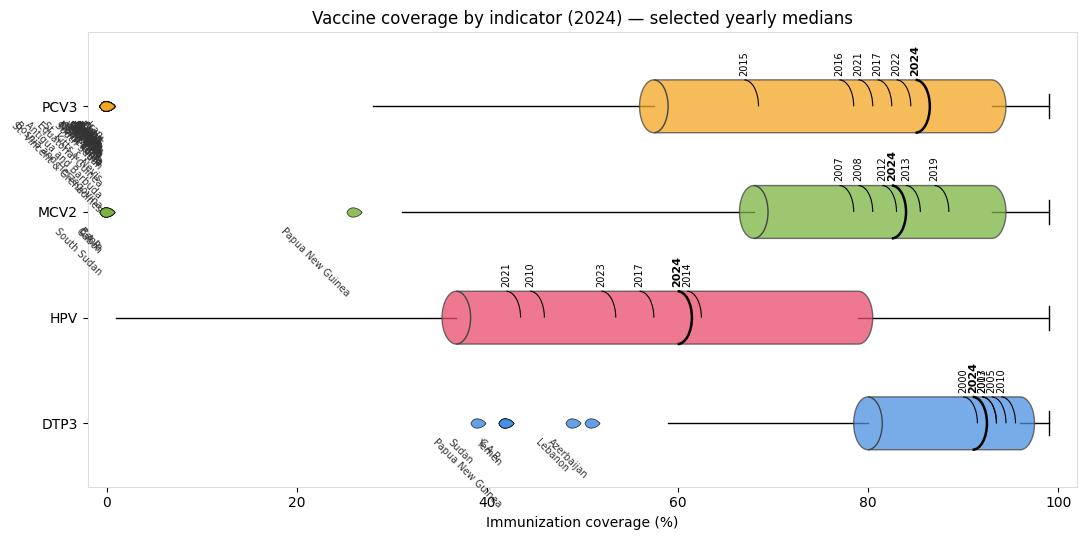

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Arc, Polygon, Ellipse



























































import pandas as pd
import numpy as np
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
TARGET_YEAR = 2024
N_KEEP = 5
BOX_H = 0.5
ELLIPSE_W = 1.5
BACK_CAP_W = 1.5
EXCLUDE_MEDIANS = {('DTP3', 2001), ('MCV2', 2021)}
MIN_DIST_FROM_CURRENT = 1.0

# Country code → short name mapping (for outlier labels)
code_to_name = (vaccine_df.drop_duplicates(subset='LocationCode')
                          .set_index('LocationCode')['LocationShort']
                          .to_dict())

recent = vaccine_all_years[
    (vaccine_all_years['TimeDim'] == TARGET_YEAR) &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
].copy()
recent['NumericValue'] = pd.to_numeric(recent['NumericValue'], errors='coerce')
recent = recent.dropna(subset=['NumericValue'])
groups = [recent[recent['Vaccine'] == v]['NumericValue'].values for v in order]

fig, ax = plt.subplots(figsize=(11, 5.5))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

for box in bp['boxes']:    box.set_visible(False)
for med in bp['medians']:  med.set_visible(False)
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP); flier.set_markersize(12)
    flier.set_markerfacecolor(color); flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5); flier.set_alpha(0.85)
    flier.set_linestyle('none')

for w in bp['whiskers']: w.set_zorder(2)
for c in bp['caps']:     c.set_zorder(2)
for f in bp['fliers']:   f.set_zorder(5)

for i, vaccine in enumerate(order):
    y_pos = i + 1
    vacc_data = recent[recent['Vaccine'] == vaccine]
    if vacc_data.empty:
        continue
    vals_2024 = vacc_data['NumericValue'].values
    q1, q3 = np.percentile(vals_2024, [25, 75])
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    median_2024 = np.median(vals_2024)
    color = colors[i]

    # Cylinder = single capsule polygon
    body_pts = []
    t1 = np.linspace(np.pi/2, 3*np.pi/2, 30)
    body_pts.extend([(q1 + ELLIPSE_W*np.cos(a),
                      y_pos + (BOX_H/2)*np.sin(a)) for a in t1])
    body_pts.append((q3, y_pos - BOX_H/2))
    t2 = np.linspace(-np.pi/2, np.pi/2, 30)
    body_pts.extend([(q3 + BACK_CAP_W*np.cos(a),
                      y_pos + (BOX_H/2)*np.sin(a)) for a in t2])
    ax.add_patch(Polygon(body_pts, closed=True,
                         facecolor=color, alpha=0.75,
                         edgecolor='#444', lw=1, zorder=2.5))

    ax.add_patch(Arc((q1, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=-90, theta2=90, color='#444', lw=1, zorder=2.7))

    # 2024 median: right-half ellipse
    ax.add_patch(Arc((median_2024, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=-90, theta2=90,
                     color='black', lw=1.8, zorder=3.5))
    ax.annotate(str(TARGET_YEAR),
                (median_2024, y_pos + BOX_H/2 + 0.04),
                ha='center', va='bottom', fontsize=8, fontweight='bold',
                rotation=90, color='black')

    # Historical medians: top-right quarter
    vm = (medians[(medians['Vaccine'] == vaccine) &
                  (medians['Year'] != TARGET_YEAR)]
          .sort_values('Year').reset_index(drop=True))
    excl = {y for v, y in EXCLUDE_MEDIANS if v == vaccine}
    vm = vm[~vm['Year'].isin(excl)]
    vm_in = vm[(vm['Median'] >= q1) & (vm['Median'] <= q3)]
    vm_in = vm_in[abs(vm_in['Median'] - median_2024) >= MIN_DIST_FROM_CURRENT]

    if not vm_in.empty:
        if len(vm_in) > N_KEEP:
            srt = vm_in.sort_values('Median').reset_index(drop=True)
            targets = np.linspace(srt['Median'].min(), srt['Median'].max(), N_KEEP)
            chosen = []
            for t in targets:
                avail = srt[~srt.index.isin(chosen)]
                chosen.append((avail['Median'] - t).abs().idxmin())
            selected = srt.loc[chosen]
        else:
            selected = vm_in
        for year, val in zip(selected['Year'].values, selected['Median'].values):
            ax.add_patch(Arc((val, y_pos), 2*ELLIPSE_W, BOX_H,
                             theta1=0, theta2=90,
                             color='black', lw=0.8, zorder=3.4))
            ax.annotate(str(year), (val, y_pos + BOX_H/2 + 0.04),
                        ha='center', va='bottom', fontsize=7,
                        rotation=90, color='black')

    # --- Annotate outliers with country names at -45° ---
    outliers = vacc_data[(vacc_data['NumericValue'] < lo_fence) |
                         (vacc_data['NumericValue'] > hi_fence)]
    for _, row in outliers.iterrows():
        name = code_to_name.get(row['SpatialDim'], row['SpatialDim'])
        ax.annotate(name,
                    xy=(row['NumericValue'], y_pos),
                    xytext=(-2, -10), textcoords='offset points',
                    rotation=-45, ha='right', va='top',
                    fontsize=7, color='#333')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_ylim(0.4, 4.7)
ax.set_title(f'Vaccine coverage by indicator ({TARGET_YEAR}) — selected yearly medians')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_cylinder_syringes.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [63]:
# Country-level rows only (excludes regional/global aggregates)
country_rows = vaccine_all_years[vaccine_all_years['SpatialDimType'] == 'COUNTRY'].copy()
country_rows['NumericValue'] = pd.to_numeric(country_rows['NumericValue'], errors='coerce')
country_rows = country_rows.dropna(subset=['NumericValue'])

print("=== WHO Immunization Coverage Data ===")
print(f"Source: WHO GHO OData API (https://ghoapi.azureedge.net/api/)")
print(f"Underlying data: WUENIC — WHO/UNICEF Estimates of National Immunization Coverage")
print()
print(f"Total rows (all spatial levels): {len(vaccine_all_years):,}")
print(f"Country-level rows:              {len(country_rows):,}")
print()
print(f"Years covered: {country_rows['TimeDim'].min()}–{country_rows['TimeDim'].max()}"
      f"  ({country_rows['TimeDim'].nunique()} years)")
print(f"Countries:     {country_rows['SpatialDim'].nunique()}")
print()

# Combined summary: count, n_countries, median per year per vaccine
summary = (country_rows
           .groupby(['Vaccine', 'TimeDim'])
           .agg(n_rows=('NumericValue', 'size'),
                n_countries=('SpatialDim', 'nunique'),
                median=('NumericValue', 'median'))
           .reset_index()
           .rename(columns={'TimeDim': 'Year'})
           .sort_values(['Vaccine', 'Year']))

print("Per-year summary (rows / countries / median):")
print(summary.to_string(index=False))

# Optional: pivot just the medians for a compact year × vaccine table
print("\nMedian coverage (%) — Vaccine × Year:")
print(summary.pivot(index='Year', columns='Vaccine', values='median').round(1))

# Save if you want it on disk
summary.to_csv('CSV_files/vaccine_yearly_summary.csv', index=False)

=== WHO Immunization Coverage Data ===
Source: WHO GHO OData API (https://ghoapi.azureedge.net/api/)
Underlying data: WUENIC — WHO/UNICEF Estimates of National Immunization Coverage

Total rows (all spatial levels): 14,988
Country-level rows:              14,086

Years covered: 2000–2024  (25 years)
Countries:     194

Per-year summary (rows / countries / median):
Vaccine  Year  n_rows  n_countries  median
   DTP3  2000     191          191    90.0
   DTP3  2001     191          191    91.0
   DTP3  2002     192          192    91.0
   DTP3  2003     192          192    92.0
   DTP3  2004     192          192    91.5
   DTP3  2005     192          192    93.0
   DTP3  2006     193          193    93.0
   DTP3  2007     193          193    94.0
   DTP3  2008     193          193    93.0
   DTP3  2009     193          193    94.0
   DTP3  2010     193          193    94.0
   DTP3  2011     194          194    94.0
   DTP3  2012     194          194    94.0
   DTP3  2013     194          

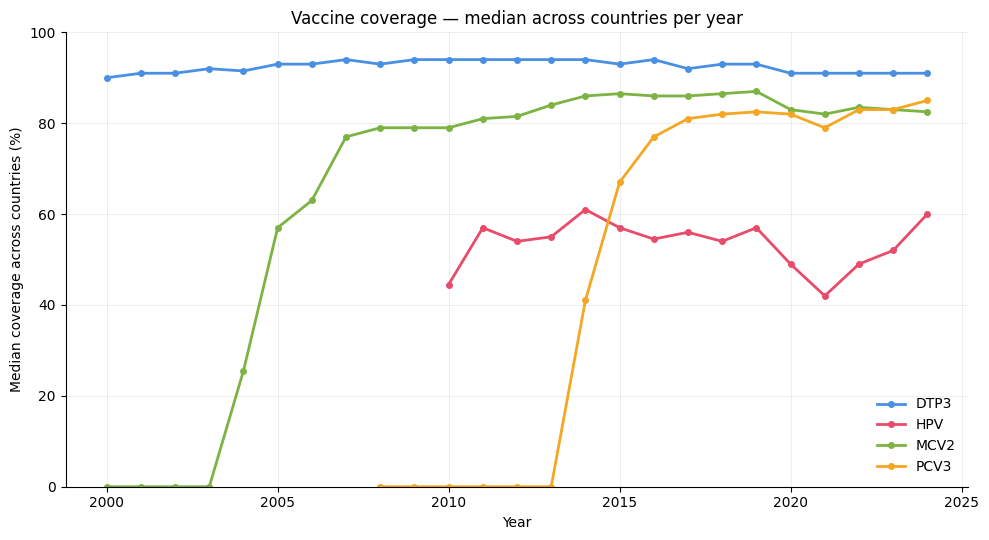

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

os.makedirs('Plot_pictures', exist_ok=True)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = {'DTP3': '#4A90E2', 'HPV': '#E94B6A', 'MCV2': '#7CB342', 'PCV3': '#F5A623'}

# === PLOT 1: medians over the years (line plot) ===
fig, ax = plt.subplots(figsize=(10, 5.5))
for vaccine in order:
    sub = medians[medians['Vaccine'] == vaccine].sort_values('Year')
    ax.plot(sub['Year'], sub['Median'],
            label=vaccine, color=colors[vaccine],
            linewidth=2, marker='o', markersize=4)

ax.set_xlabel('Year')
ax.set_ylabel('Median coverage across countries (%)')
ax.set_title('Vaccine coverage — median across countries per year')
ax.set_ylim(0, 100)
ax.legend(loc='lower right', frameon=False)
ax.grid(alpha=0.3, linewidth=0.5)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_medians_over_years.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\3700524655.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=recent, x='Vaccine', y='NumericValue',


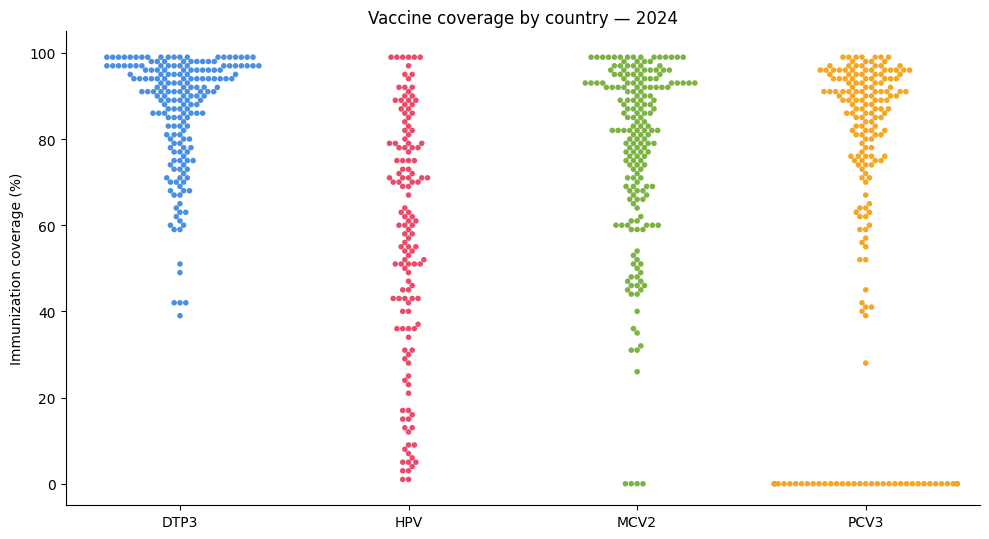

In [65]:
# === PLOT 2: swarmplot of 2024 country values ===
TARGET_YEAR = 2024
recent = vaccine_all_years[
    (vaccine_all_years['TimeDim'] == TARGET_YEAR) &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
].copy()
recent['NumericValue'] = pd.to_numeric(recent['NumericValue'], errors='coerce')
recent = recent.dropna(subset=['NumericValue'])

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.swarmplot(data=recent, x='Vaccine', y='NumericValue',
              order=order, palette=colors, size=4, ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Immunization coverage (%)')
ax.set_title(f'Vaccine coverage by country — {TARGET_YEAR}')
ax.set_ylim(-5, 105)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(f'Plot_pictures/vaccine_swarm_{TARGET_YEAR}.png',
            dpi=300, bbox_inches='tight')
plt.show()

# coverage = 0

Most of those 0%s are real zeros, but they don't mean "0% of children who should be vaccinated were vaccinated" — they mean the vaccine isn't part of that country's routine immunization schedule.

WHO/UNICEF's WUENIC methodology assigns 0% to countries that have not introduced the vaccine nationally. So a country with 0% PCV3 isn't failing to deliver — it simply hasn't included PCV3 in its routine programme. (A truly missing data point would come back as NaN, not 0.)

This is the most common explanation for:

PCV3 zeros — quite a few countries still haven't introduced PCV (notably some in Eastern Europe and the Middle East). Worldwide rollout was driven heavily by Gavi from ~2009, and high-income non-Gavi countries adopted on their own timelines.
MCV2 zeros — many countries deliver the 2nd measles dose at school age rather than infancy, and a handful of countries don't have a routine 2nd dose at all.

In [66]:
zero_counts = (recent[recent['NumericValue'] == 0]
               .groupby('Vaccine')['SpatialDim'].nunique()
               .reindex(order, fill_value=0))
print(zero_counts)

Vaccine
DTP3     0
HPV      0
MCV2     4
PCV3    37
Name: SpatialDim, dtype: int64


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_11208\2414211310.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)


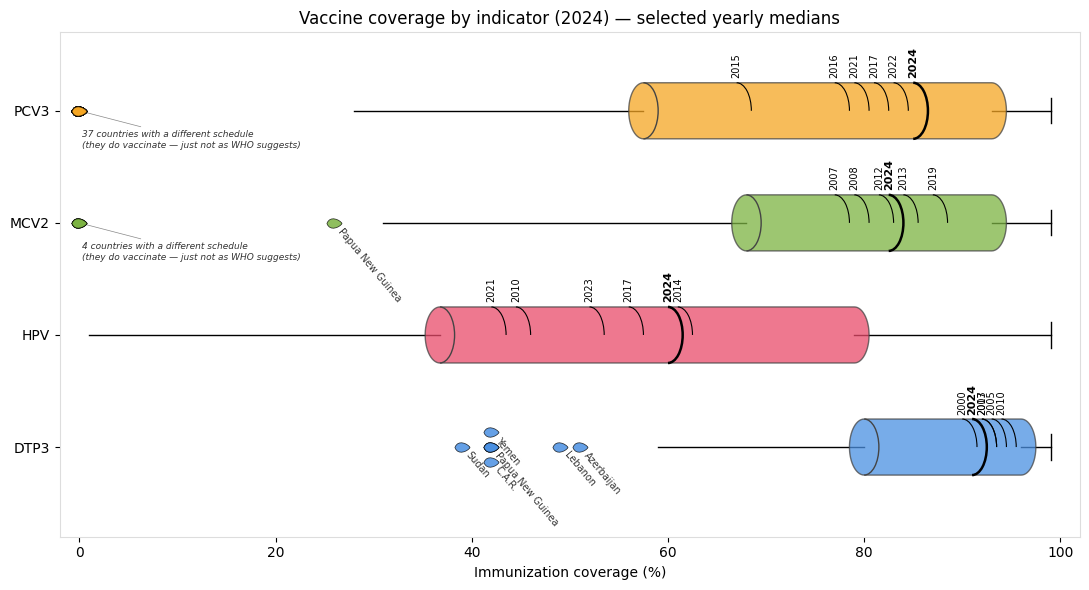

In [104]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Arc, Polygon, Ellipse
import pandas as pd
import numpy as np
import os

os.makedirs('Plot_pictures', exist_ok=True)

DROP = Path(
    [(1, 0), (0.7, -0.5), (-0.6, -1.1), (-1, 0),
     (-0.6, 1.1), (0.7, 0.5), (1, 0)],
    [Path.MOVETO] + [Path.CURVE4] * 6,
)

order = ['DTP3', 'HPV', 'MCV2', 'PCV3']
colors = ['#4A90E2', '#E94B6A', '#7CB342', '#F5A623']
TARGET_YEAR = 2024
N_KEEP = 5
BOX_H = 0.5
ELLIPSE_W = 1.5
BACK_CAP_W = 1.5
EXCLUDE_MEDIANS = {('DTP3', 2001), ('MCV2', 2021)}
MIN_DIST_FROM_CURRENT = 1.0

code_to_name = (vaccine_df.drop_duplicates(subset='LocationCode')
                          .set_index('LocationCode')['LocationShort']
                          .to_dict())

recent = vaccine_all_years[
    (vaccine_all_years['TimeDim'] == TARGET_YEAR) &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
].copy()
recent['NumericValue'] = pd.to_numeric(recent['NumericValue'], errors='coerce')
recent = recent.dropna(subset=['NumericValue'])
groups = [recent[recent['Vaccine'] == v]['NumericValue'].values for v in order]

fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(groups, vert=False, patch_artist=True, labels=order)

for box in bp['boxes']:    box.set_visible(False)
for med in bp['medians']:  med.set_visible(False)
for i, cap in enumerate(bp['caps']):
    if i % 2 == 0:
        cap.set_visible(False)

for flier, color in zip(bp['fliers'], colors):
    flier.set_marker(DROP); flier.set_markersize(12)
    flier.set_markerfacecolor(color); flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5); flier.set_alpha(0.85)
    flier.set_linestyle('none')

for w in bp['whiskers']: w.set_zorder(2)
for c in bp['caps']:     c.set_zorder(2)
for f in bp['fliers']:   f.set_zorder(5)

for i, vaccine in enumerate(order):
    y_pos = i + 1
    vacc_data = recent[recent['Vaccine'] == vaccine]
    if vacc_data.empty:
        continue
    vals_2024 = vacc_data['NumericValue'].values
    q1, q3 = np.percentile(vals_2024, [25, 75])
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    median_2024 = np.median(vals_2024)
    color = colors[i]

    # Cylinder
    body_pts = []
    t1 = np.linspace(np.pi/2, 3*np.pi/2, 30)
    body_pts.extend([(q1 + ELLIPSE_W*np.cos(a),
                      y_pos + (BOX_H/2)*np.sin(a)) for a in t1])
    body_pts.append((q3, y_pos - BOX_H/2))
    t2 = np.linspace(-np.pi/2, np.pi/2, 30)
    body_pts.extend([(q3 + BACK_CAP_W*np.cos(a),
                      y_pos + (BOX_H/2)*np.sin(a)) for a in t2])
    ax.add_patch(Polygon(body_pts, closed=True,
                         facecolor=color, alpha=0.75,
                         edgecolor='#444', lw=1, zorder=2.5))
    ax.add_patch(Arc((q1, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=-90, theta2=90, color='#444', lw=1, zorder=2.7))

    # 2024 median
    ax.add_patch(Arc((median_2024, y_pos), 2*ELLIPSE_W, BOX_H,
                     theta1=-90, theta2=90,
                     color='black', lw=1.8, zorder=3.5))
    ax.annotate(str(TARGET_YEAR),
                (median_2024, y_pos + BOX_H/2 + 0.04),
                ha='center', va='bottom', fontsize=8, fontweight='bold',
                rotation=90, color='black')

    # Historical medians
    vm = (medians[(medians['Vaccine'] == vaccine) &
                  (medians['Year'] != TARGET_YEAR)]
          .sort_values('Year').reset_index(drop=True))
    excl = {y for v, y in EXCLUDE_MEDIANS if v == vaccine}
    vm = vm[~vm['Year'].isin(excl)]
    vm_in = vm[(vm['Median'] >= q1) & (vm['Median'] <= q3)]
    vm_in = vm_in[abs(vm_in['Median'] - median_2024) >= MIN_DIST_FROM_CURRENT]
    if not vm_in.empty:
        if len(vm_in) > N_KEEP:
            srt = vm_in.sort_values('Median').reset_index(drop=True)
            targets = np.linspace(srt['Median'].min(), srt['Median'].max(), N_KEEP)
            chosen = []
            for t in targets:
                avail = srt[~srt.index.isin(chosen)]
                chosen.append((avail['Median'] - t).abs().idxmin())
            selected = srt.loc[chosen]
        else:
            selected = vm_in
        for year, val in zip(selected['Year'].values, selected['Median'].values):
            ax.add_patch(Arc((val, y_pos), 2*ELLIPSE_W, BOX_H,
                             theta1=0, theta2=90,
                             color='black', lw=0.8, zorder=3.4))
            ax.annotate(str(year), (val, y_pos + BOX_H/2 + 0.04),
                        ha='center', va='bottom', fontsize=7,
                        rotation=90, color='black')

    # --- Outlier annotations: group the zeros, label the rest individually ---
    outliers = vacc_data[(vacc_data['NumericValue'] < lo_fence) |
                         (vacc_data['NumericValue'] > hi_fence)]
    zeros = outliers[outliers['NumericValue'] == 0]
    non_zeros = outliers[outliers['NumericValue'] != 0]

    # Group label for the zero cluster
    if len(zeros) > 0:
        note = (f"{len(zeros)} countries with a different schedule\n"
                f"(they do vaccinate — just not as WHO suggests)")
        ax.annotate(note,
                    xy=(0, y_pos),
                    xytext=(2, -14), textcoords='offset points',
                    ha='left', va='top',
                    fontsize=6.5, style='italic', color='#333',
                    arrowprops=dict(arrowstyle='-', color='#888', lw=0.5))

    # --- Individual drops + labels for non-zero outliers ---
    # Distribute ties around the line: in-line, then up, then down, then further up, etc.
    LABEL_X_OFFSET   = 1.5
    LABEL_Y_OFFSET   = -7
    JITTER_Y_STEP    = 0.13
    LABEL_ROTATION   = -50
    LABEL_FONTSIZE   = 7

    seen = {}
    for _, row in non_zeros.iterrows():
        val = row['NumericValue']
        n_existing = seen.get(val, 0)
        seen[val] = n_existing + 1

        if n_existing == 0:
            drop_y = y_pos                       # 1st drop sits on the line
        else:
            step = (n_existing + 1) // 2         # 1, 1, 2, 2, ...
            sign = 1 if n_existing % 2 == 1 else -1   # +,-,+,-,...
            drop_y = y_pos + sign * JITTER_Y_STEP * step
            ax.scatter([val], [drop_y], marker=DROP, s=144,
                    color=color, edgecolor='black', linewidth=0.5,
                    alpha=0.85, zorder=5)

        name = code_to_name.get(row['SpatialDim'], row['SpatialDim'])
        ax.annotate(name,
                    xy=(val, drop_y),
                    xytext=(LABEL_X_OFFSET, LABEL_Y_OFFSET),
                    textcoords='offset points',
                    rotation=LABEL_ROTATION, rotation_mode='anchor',
                    ha='left', va='bottom',
                    fontsize=LABEL_FONTSIZE, color='#333')

ax.set_xlabel('Immunization coverage (%)')
ax.set_xlim(-2, 102)
ax.set_ylim(0.2, 4.7)
ax.set_title(f'Vaccine coverage by indicator ({TARGET_YEAR}) — selected yearly medians')

for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('Plot_pictures/vaccine_cylinder_syringes.png',
            dpi=300, bbox_inches='tight')
plt.show()

1. The 2021 dip — yes, that's the pandemic.

It's well documented: WHO/UNICEF flagged 2020–2021 as the largest sustained drop in childhood immunization in ~30 years. Globally, DTP3 coverage fell from ~86% (2019) → ~81% (2021). The dip shows up across all four indicators because the same mechanisms hit all routine programmes:

Lockdowns and movement restrictions kept children from clinics
Health workers and supplies redirected to COVID response
Outreach and school-based campaigns suspended (this hit HPV especially hard since it's typically delivered in schools)
Vaccine confidence dipped in some places
You should see partial recovery from 2022 onwards — DTP3 and MCV2 mostly snapped back, PCV3 and HPV more slowly.

2. HPV fluctuation — yes, mostly a composition effect.

In [105]:
hpv = vaccine_all_years[
    (vaccine_all_years['Vaccine'] == 'HPV') &
    (vaccine_all_years['SpatialDimType'] == 'COUNTRY')
]
hpv['NumericValue'] = pd.to_numeric(hpv['NumericValue'], errors='coerce')

# Number of reporting countries per year
print(hpv.dropna(subset=['NumericValue'])
         .groupby('TimeDim')['SpatialDim'].nunique())

TimeDim
2010     18
2011     26
2012     35
2013     43
2014     50
2015     58
2016     62
2017     73
2018     83
2019     89
2020     97
2021    106
2022    117
2023    132
2024    140
Name: SpatialDim, dtype: int64


# description for the horizontal one

Vaccine coverage by indicator (2024)

Boxplot of national immunization coverage across countries reporting to the WHO GHO (WUENIC estimates) for four routine vaccines:

DTP3 — Diphtheria-tetanus-pertussis (DTP3) immunization coverage among 1-year-olds (%)
HPV — Human papillomavirus (HPV) immunization coverage estimates among the primary target cohort (9–14-year-old girls) (%)
MCV2 — Measles-containing-vaccine second-dose (MCV2) immunization coverage by the locally recommended age (%)
PCV3 — Pneumococcal conjugate 3rd dose (PCV3) immunization coverage among 1-year-olds (%)
Each box/syringe cylinder shows the inter-quartile range across countries; the bold curve is the 2024 median, the thinner arcs are selected historical-year medians within the IQR. The lower-whisker cap is omitted on purpose — the cylindrical box and one-sided whisker echo a syringe shape, with low-coverage countries (outliers) shown as drops past the needle.

The medians do not climb monotonically over time. The 2020–2021 dip across all four indicators reflects the COVID-19 pandemic, which disrupted routine immunization, school-based delivery (especially HPV), and outreach campaigns. HPV's longer-term wobble is partly a composition effect: each year's median is computed across whichever countries are currently reporting, and as Gavi-supported low- and middle-income countries introduced HPV from the 2010s onwards, the pool of reporters shifted — pulling the median around independently of any individual country's progress.

Note on 0% outliers (PCV3, MCV2): these don't mean those countries have zero coverage in practice. WUENIC assigns 0% when a vaccine has not been introduced into a country's national routine schedule. Most of those countries do still vaccinate — just on a different schedule than WHO recommends.

W — WHO
U — UNICEF
E — Estimates of
N — National
I — Immunization
C — Coverage